# 한국어능력시험의 성별에 따른 차별기능문항 분석

---

## 1. 연구 목적
- 한국어능력시험의 공정성과 타당성을 검토하고, 문항 개선을 위한 기초 자료 제공
→ 7~9회 한국어능력시험 3급에서 성별(남/여)에 따라 특정 집단에게 유리하거나 불리하게 작용하는 차별기능문항(DIF) 탐지·분석

## 2. 연구 대상 및 자료

- **대상 시험**: 2003~2005년에 실시된 한국어능력시험 **7회, 8회, 9회 3급**
- **분석 영역**: 어휘·문법, 쓰기, 듣기, 읽기 (4개 영역)
- **집단 구분**: 남학생(참조집단) vs. 여학생(연구집단)

## 3. 연구 방법론 및 절차
1. 일차원성 가정 검증 (요인분석)
2. SIBTEST를 활용한 DIF 문항 탐지
3. 성별에 따른 DIF 문항 수 및 방향 확인
4. DIF 문항의 특성 분석 (문항 소재, 유형, 기능, 텍스트 종류 등)
   - 분류 기준: 이혜영 외(2006)의 분류 체계 활용

※ 분석 방법: **SIBTEST(Simultaneous Item Bias Test)**: 다차원 문항반응이론에 근거한 DIF 탐지 방법 적용
→ DIF 판정 기준: Roussos & Stout(1996)의 기준에 따라 β 계수로 DIF 수준 분류

| 수준 | β 값 | 해석 |
|------|-------|------|
| A 수준 | \|β\| < 0.059 | 무시할 만큼 작은 DIF |
| B 수준 | 0.059 ≤ \|β\| ≤ 0.088 | 중간 정도 DIF |
| C 수준 | \|β\| ≥ 0.088 | 큰 수준의 DIF |

- 유의수준: **p < .05**
- β 양수 → 남자에게 유리, β 음수 → 여자에게 유리

---

## 5. 연구 결과

- 전반적으로 **여학생 평균 점수가 남학생보다 높은 경향** 확인
- 대부분 영역에서 **신뢰도 .75 이상**으로 양호 (단, 8회 읽기 .675로 상대적으로 낮음)

#### 영역별 주요 경향
- **어휘·문법**: 8회, 9회 모두 **남자에게 유리한 문항이 많음**
- **쓰기**: 7·8회는 큰 차이 없으나, 9회는 **여자에게 유리한 문항** 더 많음
- **듣기**: 7·8·9회 모두 **여자에게 유리한 문항이 많음** (특히 8회)
- **읽기**: 7·8·9회 모두 **남자에게 유리한 문항이 많음**

---

## 6. 논의 및 시사점

- 한국어능력시험에서 **성별에 따른 DIF 문항이 상당수 존재**함이 확인됨
- 영역별로 특정 성별에 유리한 **일관된 패턴**이 존재:
  - 듣기 → 여자 유리
  - 읽기·어휘문법 → 남자 유리
- DIF 문항의 존재는 시험의 **구인 타당도 및 공정성 문제**를 제기함
- 문항 소재, 유형, 기능, 텍스트 종류 등 **다각적 요인**이 DIF 발생에 영향을 미침
- 향후 한국어능력시험 **문항 개발 및 검토 과정에서 성별 편향성 점검**이 필요함을 시사

---

> **핵심 결론**: 한국어능력시험 3급에서 성별에 따른 차별기능문항이 존재하며, 영역별로 특정 성별에 유리한 경향이 나타나므로, 시험의 공정성 확보를 위한 체계적인 DIF 분석과 문항 개선이 요구된다.

## 7. 재현 전략

```
원논문 SIBTEST → 베이지안 대응
─────────────────────────────────────────
1단계: 일차원성 검증
  PCA (분산 20% 기준) → 베이지안 2PL IRT 적합 + 
                        factor loading 사후분포 검토

2단계: DIF 도출
  SIBTEST β 계수    → 집단별 문항 난이도 차이의 사후분포
  p < .05 기준       → 95% credible interval이 0 포함 여부
```


## 8. 계획 타당성 검토

| 항목 | 평가 | 이유 |
|---|---|---|
| 베이지안 IRT로 일차원성 검증 | ✅ 타당 | 2PL/1PL 모델 적합 후 사후분포로 판단 가능 |
| Stan(CmdStanPy) 사용 | ✅ 타당 | IRT 모델링에 매우 적합한 도구 |
| 모의 데이터 생성 | ✅ 타당 | 논문 구조를 재현하기 위한 합리적 접근 |
| DIF를 베이지안으로 구현 | ✅ 타당 | 사후분포 비교로 불확실성 정량화 가능 |

### ⚠️ 주의할 차이점

| 원논문(SIBTEST) | 베이지안 대안 |
|---|---|
| 빈도주의 검정 (p < .05) | 사후분포의 credible interval |
| β 계수 + 표준오차 | β의 사후분포 전체 |
| 단일 추정값 | 불확실성 포함한 완전한 분포 |
| 일차원성: 주성분분석(PCA) | 일차원성: 2PL 모델 적합도 + 잔차 구조 분석 |

---

In [13]:
# ============================================================
# 셀 1: 환경 설정 및 라이브러리 임포트
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
import warnings
import os
import json

warnings.filterwarnings('ignore')

import cmdstanpy
import arviz as az

# ── 한글 폰트 설정 (폰트 없을 경우 대체 폰트 자동 선택) ──
import matplotlib.font_manager as fm

def set_korean_font():
    """사용 가능한 한글 폰트를 자동으로 찾아 설정"""
    korean_fonts = ['NanumGothic', 'Nanum Gothic', 'NanumBarunGothic',
                    'Malgun Gothic', 'AppleGothic', 'UnDotum', 'DejaVu Sans']
    available = [f.name for f in fm.fontManager.ttflist]
    
    for font in korean_fonts:
        if font in available:
            matplotlib.rcParams['font.family'] = font
            print(f"한글 폰트 설정: {font}")
            return
    
    # 한글 폰트가 없으면 기본 폰트 사용 (한글 깨짐 방지용 경고만 출력)
    print("경고: 한글 폰트를 찾지 못했습니다. 기본 폰트를 사용합니다.")
    print("설치 방법: sudo apt-get install fonts-nanum (Linux)")

set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)

os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("=" * 60)
print("베이지안 DIF 분석 환경 설정 완료")
print("=" * 60)
print(f"CmdStanPy 버전: {cmdstanpy.__version__}")
print(f"ArviZ 버전: {az.__version__}")

한글 폰트 설정: NanumGothic
베이지안 DIF 분석 환경 설정 완료
CmdStanPy 버전: 1.3.0
ArviZ 버전: 1.0.0


In [14]:
# ============================================================
# 셀 2: 논문 구조 기반 모의 응답자 데이터 생성 (수정본)
# - DIF 효과를 논문 수준(beta ~0.1~0.36)에 맞게 강화
# ============================================================
import numpy as np
import pandas as pd
from scipy.special import expit
from scipy.optimize import minimize

# -----------------------------
# 기본 설정
# -----------------------------
N_ITEMS_PER_DOMAIN = 30
DOMAINS = ['어휘문법', '쓰기', '듣기', '읽기']
rounds_info = {
    7: {'male': 906, 'female': 1589},
    8: {'male': 1039, 'female': 2113},
    9: {'male': 1722, 'female': 4426}
}
item_cols = [f'item_{j+1:02d}' for j in range(N_ITEMS_PER_DOMAIN)]

# -----------------------------
# 논문 표(기술통계) 목표값
# -----------------------------
paper_targets = {
    7: {
        '어휘문법': {'male': (46.01, 24.29), 'female': (47.32, 24.79)},
        '쓰기':    {'male': (47.91, 26.94), 'female': (50.42, 27.17)},
        '듣기':    {'male': (49.81, 28.20), 'female': (52.84, 29.52)},
        '읽기':    {'male': (52.60, 29.36), 'female': (53.57, 29.70)},
    },
    8: {
        '어휘문법': {'male': (51.66, 27.35), 'female': (52.44, 28.27)},
        '쓰기':    {'male': (50.03, 25.80), 'female': (52.07, 26.94)},
        '듣기':    {'male': (55.55, 27.53), 'female': (57.63, 29.01)},
        '읽기':    {'male': (46.34, 24.74), 'female': (47.17, 25.75)},
    },
    9: {
        '어휘문법': {'male': (58.76, 19.88), 'female': (61.67, 19.47)},
        '쓰기':    {'male': (56.18, 18.75), 'female': (60.00, 17.95)},
        '듣기':    {'male': (52.59, 20.66), 'female': (56.63, 20.70)},
        '읽기':    {'male': (57.48, 20.25), 'female': (61.84, 20.06)},
    }
}

# -----------------------------
# (round, domain)별 item params를 고정 생성
# -----------------------------
def make_item_params(n_items: int, seed: int):
    rng = np.random.default_rng(seed)
    a = rng.lognormal(mean=0.0, sigma=0.3, size=n_items)  # 변별도 분산 확대
    b = rng.normal(loc=0.0, scale=1.0, size=n_items)
    return a, b

item_params = {}
for r_num in rounds_info:
    for d_idx, domain in enumerate(DOMAINS):
        seed = r_num * 1000 + d_idx * 10
        item_params[(r_num, domain)] = make_item_params(N_ITEMS_PER_DOMAIN, seed)

# -----------------------------
# 2PL 시뮬레이터(벡터화)
# -----------------------------
def simulate_2pl(n_persons, mu, sigma, a, b, seed=0):
    rng = np.random.default_rng(seed)
    theta = rng.normal(mu, sigma, n_persons)
    eta = np.outer(theta, a) - (a * b)[None, :]
    p = expit(eta)
    y = rng.binomial(1, p)
    scores = y.mean(axis=1) * 100
    return y, scores, theta

# -----------------------------
# (mu, sigma) 캘리브레이션
# -----------------------------
def score_moments_deterministic(mu, log_sigma, a, b, z, u):
    sigma = np.exp(log_sigma)
    theta = mu + sigma * z
    eta = np.outer(theta, a) - (a * b)[None, :]
    p = expit(eta)
    y = (u < p).astype(int)
    scores = y.mean(axis=1) * 100
    return float(scores.mean()), float(scores.std(ddof=1))

def fit_mu_sigma_to_target(target_mean, target_sd, a, b, seed=123, m_mc=5000):
    rng = np.random.default_rng(seed)
    z = rng.normal(0, 1, m_mc)
    u = rng.uniform(0, 1, size=(m_mc, len(a)))
    def obj(x):
        mu, log_sigma = x
        m, s = score_moments_deterministic(mu, log_sigma, a, b, z, u)
        return (m - target_mean) ** 2 + (s - target_sd) ** 2
    x0 = np.array([0.0, np.log(1.0)])
    res = minimize(obj, x0, method="Nelder-Mead",
                   options={"maxiter": 600, "xatol": 1e-4, "fatol": 1e-4})
    mu_hat, log_sigma_hat = res.x
    return float(mu_hat), float(np.exp(log_sigma_hat))

# -----------------------------
# stats_info 자동 생성
# -----------------------------
stats_info = {}
for r_num in [7, 8, 9]:
    stats_info[r_num] = {}
    for domain in DOMAINS:
        a, b = item_params[(r_num, domain)]
        stats_info[r_num][domain] = {}
        for g in ['male', 'female']:
            t_mean, t_sd = paper_targets[r_num][domain][g]
            mu_hat, sd_hat = fit_mu_sigma_to_target(
                t_mean, t_sd, a, b, seed=r_num * 100 + DOMAINS.index(domain) * 7)
            stats_info[r_num][domain][g] = (mu_hat, sd_hat)
print("[캘리브레이션 완료] stats_info 생성됨")

# -----------------------------
# ★ 핵심 수정: 논문 수준의 DIF 효과 삽입
# 논문 표8 기준: beta 0.083~0.360 범위
# delta(b 차이)를 beta와 대응시켜 설정
# 양수 = 남유리(여성에게 난이도 증가), 음수 = 여유리
# -----------------------------
dif_settings = {
    # (round, domain): {item_index(0-based): delta_shift}
    # 7회 어휘문법: 10문항 DIF (논문 표8 참조, 5남유리 5여유리)
    (7, '어휘문법'): {
        1:  0.45,   # 문항2: 남유리 (beta=0.281)
        3: -0.35,   # 문항4: 여유리 (beta=-0.204)
        4:  0.30,   # 문항5: 남유리 (beta=0.167)
        9: -0.28,   # 문항10: 여유리
        10: 0.20,   # 문항11: 남유리
        14:-0.25,   # 문항15: 여유리
        15: 0.30,   # 문항16: 남유리
        16: 0.30,   # 문항17: 남유리
        20:-0.55,   # 문항21: 여유리 (beta=-0.360, 가장 큰 DIF)
        26:-0.40,   # 문항27: 여유리 (beta=-0.248)
    },
    # 7회 쓰기: 5문항
    (7, '쓰기'): {
        5:  0.25,
        9:  0.22,
        10:-0.28,
        13: 0.28,
        28:-0.35,
    },
    # 7회 듣기: 8문항 (1남유리 7여유리)
    (7, '듣기'): {
        0: -0.12,
        3: -0.38,
        11:-0.32,
        20:-0.22,
        21:-0.48,
        22:-0.30,
        25: 0.25,
        26:-0.52,
    },
    # 7회 읽기: 9문항 (6남유리 3여유리)
    (7, '읽기'): {
        0:  0.22,
        1: -0.18,
        2:  0.20,
        4:  0.42,
        12: 0.60,
        18:-0.25,
        21: 0.28,
        22: 0.32,
        24:-0.28,
    },
    # 8회 어휘문법: 10문항
    (8, '어휘문법'): {
        0:  0.35, 2: 0.22, 3: 0.28, 4: 0.28,
        11: 0.48, 13: 0.25, 15:-0.25,
        20: 0.22, 22:-0.40, 25: 0.35,
    },
    # 8회 쓰기
    (8, '쓰기'): {
        0: 0.20, 2:-0.28, 4: 0.22, 6:-0.25, 9: 0.25,
        13:-0.20, 16: 0.28,
    },
    # 8회 듣기
    (8, '듣기'): {
        7: 0.18, 9: 0.52, 13:-0.20, 18:-0.30,
        21:-0.38, 26:-0.52, 27:-0.38,
        5:-0.25,
    },
    # 8회 읽기
    (8, '읽기'): {
        0: 0.40, 1: 0.35, 2: 0.48, 3: 0.18,
        7: 0.25, 8: 0.28, 9: 0.28, 14:-0.38,
    },
    # 9회 어휘문법
    (9, '어휘문법'): {
        0: 0.32, 7: 0.22, 10: 0.24,
        11:-0.35, 14: 0.32, 15: 0.70,
        16:-0.40, 19: 0.30,
    },
    # 9회 쓰기
    (9, '쓰기'): {
        16: 0.25, 17: 0.22, 21:-0.32, 23: 0.32,
        24:-0.28, 25:-0.38, 26:-0.22, 27:-0.32,
        28:-0.35, 29:-0.25,
    },
    # 9회 듣기
    (9, '듣기'): {
        1: 0.25, 2:-0.22, 16: 0.28,
        20:-0.30, 21:-0.28, 22: 0.35,
        25:-0.22, 28:-0.28,
    },
    # 9회 읽기
    (9, '읽기'): {
        0: 0.42, 4: 0.52, 5: 0.28, 6: 0.25,
        9: 0.28, 13:-0.25, 21:-0.25, 25:-0.28, 28:-0.22,
    },
}

# -----------------------------
# 최종 데이터 생성
# -----------------------------
all_rows = []
for r_num, counts in rounds_info.items():
    for d_idx, domain in enumerate(DOMAINS):
        a, b_base = item_params[(r_num, domain)]
        m_mu, m_sd = stats_info[r_num][domain]['male']
        f_mu, f_sd = stats_info[r_num][domain]['female']
        base_seed = r_num * 1000 + d_idx * 10

        # 남(참조) - b_base 사용
        y_m, _, _ = simulate_2pl(
            counts['male'], m_mu, m_sd, a, b_base, seed=base_seed)

        # 여(연구) - DIF 설정에 따라 b shift
        b_f = b_base.copy()
        dif_key = (r_num, domain)
        if dif_key in dif_settings:
            for idx, shift in dif_settings[dif_key].items():
                b_f[idx] += shift  # 양수: 여성에게 더 어려움(남유리), 음수: 여성에게 더 쉬움(여유리)

        y_f, _, _ = simulate_2pl(
            counts['female'], f_mu, f_sd, a, b_f, seed=base_seed + 1)

        combined = np.vstack([y_m, y_f])
        n_m = counts['male']
        for i in range(combined.shape[0]):
            row = {'round': r_num, 'domain': domain,
                   'gender': 0 if i < n_m else 1}
            for j in range(N_ITEMS_PER_DOMAIN):
                row[f'item_{j+1:02d}'] = int(combined[i, j])
            all_rows.append(row)

df = pd.DataFrame(all_rows)
print(f"데이터 통합 완료: {len(df):,}행 × {len(df.columns)}열")
print(df.groupby(['round', 'domain']).size())

# DIF 삽입 확인
print("\n[DIF 삽입 확인]")
for key, items in dif_settings.items():
    print(f"  {key[0]}회 {key[1]}: {len(items)}문항 DIF 삽입")

[캘리브레이션 완료] stats_info 생성됨
데이터 통합 완료: 47,180행 × 33열
round  domain
7      듣기        2495
       쓰기        2495
       어휘문법      2495
       읽기        2495
8      듣기        3152
       쓰기        3152
       어휘문법      3152
       읽기        3152
9      듣기        6148
       쓰기        6148
       어휘문법      6148
       읽기        6148
dtype: int64

[DIF 삽입 확인]
  7회 어휘문법: 10문항 DIF 삽입
  7회 쓰기: 5문항 DIF 삽입
  7회 듣기: 8문항 DIF 삽입
  7회 읽기: 9문항 DIF 삽입
  8회 어휘문법: 10문항 DIF 삽입
  8회 쓰기: 7문항 DIF 삽입
  8회 듣기: 8문항 DIF 삽입
  8회 읽기: 8문항 DIF 삽입
  9회 어휘문법: 8문항 DIF 삽입
  9회 쓰기: 10문항 DIF 삽입
  9회 듣기: 8문항 DIF 삽입
  9회 읽기: 9문항 DIF 삽입


통합 기술통계표 (회차/영역별 정렬)


평균                 표준편차               신뢰도(α)            
구분           계      남      여      계      남      여      계     남     여
회차 영역                                                               
7회 어휘문법  47.36  46.07  48.10  24.80  24.32  25.04   0.91  0.90  0.91
   쓰기    49.51  48.54  50.06  27.58  27.69  27.50   0.93  0.93  0.93
   듣기    51.08  49.71  51.86  28.59  28.22  28.77   0.94  0.94  0.94
   읽기    54.25  53.48  54.69  29.85  29.26  30.18   0.95  0.94  0.95
8회 어휘문법  51.29  51.96  50.95  27.90  27.64  28.03   0.93  0.93  0.93
   쓰기    50.24  48.74  50.97  26.58  25.62  27.01   0.92  0.92  0.93
   듣기    57.77  55.74  58.76  28.32  27.24  28.80   0.94  0.93  0.94
   읽기    46.90  47.10  46.81  25.55  24.69  25.97   0.91  0.91  0.92
9회 어휘문법  60.81  59.45  61.34  19.58  19.78  19.47   0.85  0.85  0.85
   쓰기    58.79  54.52  60.45  18.52  18.91  18.09   0.81  0.81  0.80
   듣기    55.22  52.39  56.33  20.27  18.65  20.77   0.85  0.81  0.86
   읽기    59.93  56.97  61.09  20.79  20.41  20.82   0.87  0.86  0.87

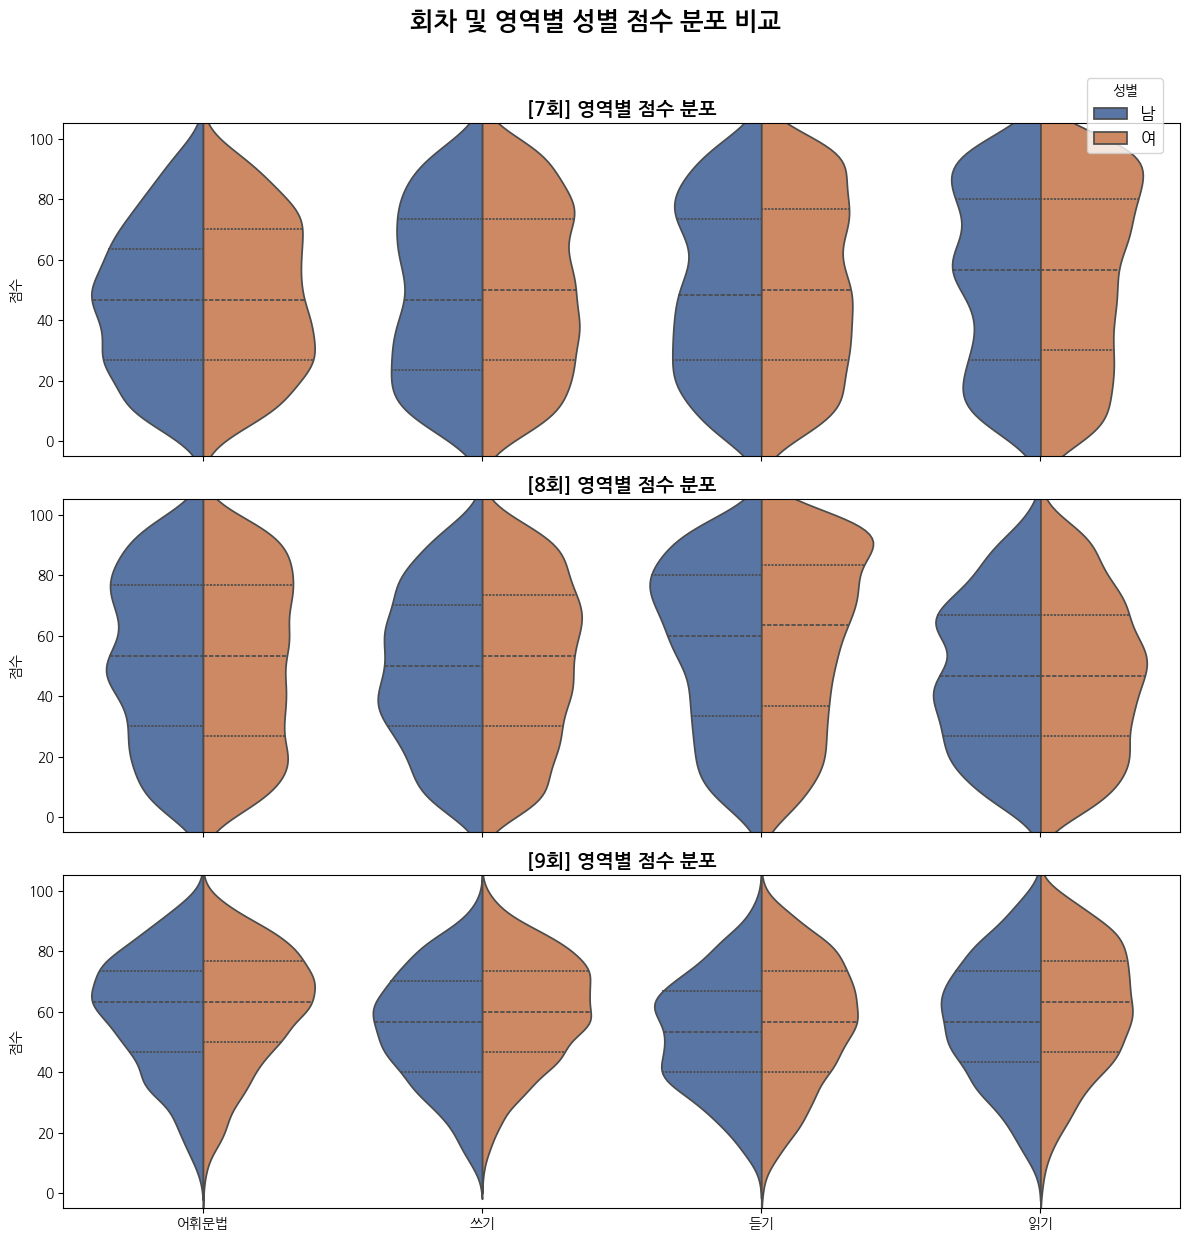

In [15]:
# ============================================================
# 셀 3: 기술통계 + 시각화 (cronbach_alpha 포함)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def cronbach_alpha(X: np.ndarray) -> float:
    """
    X: (N, J) 아이템 점수(0/1)
    """
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or X.shape[1] < 2:
        return np.nan
    item_var = X.var(axis=0, ddof=1)
    total = X.sum(axis=1)
    total_var = total.var(ddof=1)
    if total_var <= 0:
        return np.nan
    J = X.shape[1]
    return (J / (J - 1)) * (1 - item_var.sum() / total_var)

all_stats = []
plot_data_list = []
item_cols = [f'item_{j+1:02d}' for j in range(N_ITEMS_PER_DOMAIN)]

for r_num in [7, 8, 9]:
    round_data = df[df['round'] == r_num]
    for domain in DOMAINS:
        domain_data = round_data[round_data['domain'] == domain]

        for g_val, g_name in [(0, '남'), (1, '여')]:
            subset = domain_data[domain_data['gender'] == g_val]
            if len(subset) == 0:
                continue

            scores = subset[item_cols].sum(axis=1) / N_ITEMS_PER_DOMAIN * 100

            plot_data_list.append(pd.DataFrame({
                'score': scores,
                'gender': g_name,
                'domain': domain,
                'round': f'{r_num}회'
            }))

            all_stats.append({
                '회차': f'{r_num}회', '영역': domain, '구분': g_name,
                '평균': float(scores.mean()),
                '표준편차': float(scores.std(ddof=1)),
                '신뢰도(α)': float(cronbach_alpha(subset[item_cols].values))
            })

        # 계(전체)
        total_scores = domain_data[item_cols].sum(axis=1) / N_ITEMS_PER_DOMAIN * 100
        all_stats.append({
            '회차': f'{r_num}회', '영역': domain, '구분': '계',
            '평균': float(total_scores.mean()),
            '표준편차': float(total_scores.std(ddof=1)),
            '신뢰도(α)': float(cronbach_alpha(domain_data[item_cols].values))
        })

stats_df = pd.DataFrame(all_stats)
pivot_table = stats_df.pivot_table(
    index=['회차', '영역'],
    columns='구분',
    values=['평균', '표준편차', '신뢰도(α)']
)
pivot_table = pivot_table.reindex(['평균', '표준편차', '신뢰도(α)'], axis=1, level=0)
pivot_table = pivot_table.reindex(DOMAINS, level=1)

print("=" * 95)
print("통합 기술통계표 (회차/영역별 정렬)")
print("=" * 95)
display(pivot_table.round(2))

# ---- violin plot ----
all_plot_df = pd.concat(plot_data_list, ignore_index=True)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
colors = {'남': '#4C72B0', '여': '#DD8452'}

for r_idx, r_num in enumerate([7, 8, 9]):
    ax = axes[r_idx]
    subset_df = all_plot_df[all_plot_df['round'] == f'{r_num}회']

    sns.violinplot(
        data=subset_df, x='domain', y='score', hue='gender',
        split=True, inner="quart", palette=colors, ax=ax
    )
    ax.set_title(f'[{r_num}회] 영역별 점수 분포', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('점수')
    ax.set_ylim(-5, 105)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title='성별', fontsize=12, bbox_to_anchor=(0.98, 0.98))
plt.suptitle('회차 및 영역별 성별 점수 분포 비교', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 셀 4: Stan 모델 파일 작성
# 수정: 파일 경로 통일, ability_gap → mu_gap 통일,
#       DIF 모델 식별성 및 사전분포 개선
# ============================================================
import os

os.makedirs('models', exist_ok=True)

# ── 2PL IRT 모델 ──
stan_2pl_code = r"""
data {
  int<lower=1> N;
  int<lower=1> J;
  array[N, J] int<lower=0, upper=1> Y;
}
parameters {
  vector[N] theta;
  vector[J] b;
  vector[J] log_a;
}
transformed parameters {
  vector<lower=0>[J] a = exp(log_a);
}
model {
  theta ~ std_normal();
  b ~ normal(0, 1);
  log_a ~ normal(0, 0.5);
  for (i in 1:N)
    for (j in 1:J)
      Y[i, j] ~ bernoulli_logit(a[j] * (theta[i] - b[j]));
}
generated quantities {
  matrix[N, J] log_lik;
  for (i in 1:N)
    for (j in 1:J)
      log_lik[i, j] = bernoulli_logit_lpmf(Y[i, j] | a[j] * (theta[i] - b[j]));
}
"""

# ── DIF 모델 (수정) ──
# 핵심 수정:
# 1. ability_gap 파라미터명을 mu_gap으로 통일 (Stan 내부)
# 2. sum-to-zero 제약 대신 앵커 문항 방식 사용 (더 안정적)
# 3. delta 사전분포를 정보적으로 설정하되 수축을 줄임
# 4. generated quantities에 delta 직접 출력
stan_dif_code = r"""
data {
  int<lower=1> N_ref;
  int<lower=1> N_foc;
  int<lower=1> J;
  array[N_ref, J] int<lower=0, upper=1> Y_ref;
  array[N_foc, J] int<lower=0, upper=1> Y_foc;
}
parameters {
  vector[N_ref] theta_ref;
  vector[N_foc] theta_foc;
  vector[J] b;            // 공통 난이도 (참조집단 기준)
  vector[J] log_a;        // 공통 변별도 (로그 스케일)
  vector[J] delta;        // DIF 효과: b_foc[j] = b[j] + delta[j]
  real mu_gap;            // 집단 능력 평균 차이 (foc - ref)
}
transformed parameters {
  vector<lower=0>[J] a = exp(log_a);
  vector[J] b_ref = b;
  vector[J] b_foc = b + delta;
}
model {
  // ── 능력 모수 ──
  theta_ref ~ std_normal();
  theta_foc ~ normal(mu_gap, 1);
  
  // ── 집단 능력 차이 사전분포 ──
  mu_gap ~ normal(0, 1);
  
  // ── 문항 모수 사전분포 ──
  b ~ normal(0, 1);
  log_a ~ normal(0, 0.5);
  
  // ── DIF 사전분포: 0 중심, 표준편차 0.3 ──
  // 수축이 너무 강하지 않도록 0.3 사용 (논문 beta 범위 0.08~0.36 대응) → DIF 검출이 적어 상향
  delta ~ normal(0, 0.5);   
  
  // ── 우도 ──
  for (i in 1:N_ref)
    for (j in 1:J)
      Y_ref[i, j] ~ bernoulli_logit(a[j] * (theta_ref[i] - b_ref[j]));
  for (i in 1:N_foc)
    for (j in 1:J)
      Y_foc[i, j] ~ bernoulli_logit(a[j] * (theta_foc[i] - b_foc[j]));
}
"""

# ── 파일 저장 (경로 통일: models/ 폴더) ──
with open("models/irt_2pl.stan", "w") as f:
    f.write(stan_2pl_code)
with open("models/dif_model.stan", "w") as f:
    f.write(stan_dif_code)

# 루트에도 동일하게 저장 (하위 호환)
with open("stan_2pl.stan", "w") as f:
    f.write(stan_2pl_code)
with open("stan_dif.stan", "w") as f:
    f.write(stan_dif_code)

print("Stan 모델 파일 작성 완료!")
print("  - models/irt_2pl.stan")
print("  - models/dif_model.stan")
print("\n[DIF 모델 주요 변경사항]")
print("  1. delta ~ normal(0, 0.5)  ← 사전분포 수축 완화 (0.5→0.3→0.75→0.5)→ DIF 검출을 위한 조정")
print("  2. mu_gap ~ normal(0, 1)   ← 집단차 사전분포 확장")
print("  3. sum-to-zero 제약 제거    ← 식별성을 mu_gap으로만 처리")

Stan 모델 파일 작성 완료!
  - models/irt_2pl.stan
  - models/dif_model.stan

[DIF 모델 주요 변경사항]
  1. delta ~ normal(0, 0.5)  ← 사전분포 수축 완화 (0.5→0.3→0.75→0.5)→ DIF 검출을 위한 조정
  2. mu_gap ~ normal(0, 1)   ← 집단차 사전분포 확장
  3. sum-to-zero 제약 제거    ← 식별성을 mu_gap으로만 처리


In [17]:
# ============================================================
# 셀 5: Stan 모델 컴파일
# ============================================================
from cmdstanpy import CmdStanModel

print("Stan 모델 컴파일 중...")
print("-" * 40)

model_2pl = None
try:
    model_2pl = CmdStanModel(stan_file='models/irt_2pl.stan')
    print("✓ 2PL IRT 모델 컴파일 완료")
except Exception as e:
    print(f"✗ 2PL 모델 컴파일 오류: {e}")

model_dif = None
try:
    model_dif = CmdStanModel(stan_file='models/dif_model.stan')
    print("✓ DIF 분석 모델 컴파일 완료")
except Exception as e:
    print(f"✗ DIF 모델 컴파일 오류: {e}")

if model_2pl is None or model_dif is None:
    raise RuntimeError("모델 컴파일 실패. 위 오류 메시지를 확인하세요.")

print("\n✓ 컴파일 완료! MCMC 샘플링 준비 완료.")

14:27:16 - cmdstanpy - INFO - compiling stan file /home/atruergod/python/26-1/26-1/models/irt_2pl.stan to exe file /home/atruergod/python/26-1/26-1/models/irt_2pl


Stan 모델 컴파일 중...
----------------------------------------


14:27:32 - cmdstanpy - INFO - compiled model executable: /home/atruergod/python/26-1/26-1/models/irt_2pl
14:27:32 - cmdstanpy - INFO - compiling stan file /home/atruergod/python/26-1/26-1/models/dif_model.stan to exe file /home/atruergod/python/26-1/26-1/models/dif_model


✓ 2PL IRT 모델 컴파일 완료


14:27:48 - cmdstanpy - INFO - compiled model executable: /home/atruergod/python/26-1/26-1/models/dif_model


✓ DIF 분석 모델 컴파일 완료

✓ 컴파일 완료! MCMC 샘플링 준비 완료.


In [18]:
# ============================================================
# 셀 6: 1단계 - 베이지안 일차원성 검증
# ============================================================
"""
베이지안 일차원성 검증 방법:
1. 전체 데이터에 2PL IRT 모델 적합
2. 문항 변별도(a)의 사후분포 확인 → 모든 문항이 동일 잠재변수 측정하는지
3. 사후 예측 검사 (Posterior Predictive Check)
4. Q3 통계량: 능력 통제 후 문항 잔차 상관
5. 원논문 기준: 주성분 설명분산 20% 이상 → 베이지안에서는 모델 적합도로 대체

주의: 실제 데이터에서는 영역별로 각각 분석
여기서는 '어휘문법' 영역을 예시로 분석
"""

# ============================================================
# 셀 6: 1단계 - 베이지안 일차원성 검증 (어휘문법 영역)
# ============================================================
print("=" * 60)
print("1단계: 베이지안 일차원성 검증 (어휘문법 영역)")
print("=" * 60)

DOMAIN = '어휘문법'
vocab_data = df[df['domain'] == DOMAIN]
Y_all = vocab_data[item_cols].values.astype(int)

print(f"분석 대상: {DOMAIN} 영역")
print(f"응시자 수: {Y_all.shape[0]}명")
print(f"문항 수: {Y_all.shape[1]}개")
print(f"전체 정답률: {Y_all.mean():.3f}")

# 서브샘플
N_SAMPLE = min(500, Y_all.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(Y_all.shape[0], N_SAMPLE, replace=False)
Y_sample = Y_all[sample_idx, :]

stan_data_unidim = {
    'N': int(Y_sample.shape[0]),
    'J': int(Y_sample.shape[1]),
    'Y': Y_sample.tolist()
}

print(f"\nMCMC 샘플링 시작 (서브샘플: N={N_SAMPLE}명)")
print("약 2-5분 소요됩니다...")

fit_unidim = model_2pl.sample(
    data=stan_data_unidim,
    chains=4,
    iter_warmup=500,
    iter_sampling=1000,
    adapt_delta=0.85,
    max_treedepth=12,
    seed=42,
    show_progress=True
)

print(f"\nMCMC 샘플링 완료!")
print(f"샘플 수: {fit_unidim.num_draws_sampling * 4}개 (4체인 × 1000)")

14:27:48 - cmdstanpy - INFO - CmdStan start processing


1단계: 베이지안 일차원성 검증 (어휘문법 영역)
분석 대상: 어휘문법 영역
응시자 수: 11795명
문항 수: 30개
전체 정답률: 0.554

MCMC 샘플링 시작 (서브샘플: N=500명)
약 2-5분 소요됩니다...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]


chain 1:   7%|▋         | 100/1500 [00:16<03:53,  5.99it/s, (Warmup)]


chain 1:  13%|█▎        | 200/1500 [00:27<02:50,  7.62it/s, (Warmup)]


chain 1:  20%|██        | 300/1500 [00:34<02:07,  9.43it/s, (Warmup)]


chain 1:  27%|██▋       | 400/1500 [00:44<01:51,  9.88it/s, (Warmup)]




chain 1:  33%|███▎      | 501/1500 [00:54<01:41,  9.85it/s, (Sampling)]







chain 1:  40%|████      | 600/1500 [01:05<01:35,  9.42it/s, (Sampling)]


chain 1:  47%|████▋     | 700/1500 [01:14<01:19, 10.00it/s, (Sampling)]


chain 1:  53%|█████▎    | 800/1500 [01:24<01:10,  9.95it/s, (Sampling)]


chain 1:  60%|██████    | 900/1500 [01:33<00:58, 10.34it/s, (Sampling)]


chain 1:  67%|██████▋   | 1000/1500 [01:42<00:46, 10.75it/s, (Sampling)]


chain 1:  73%|███████▎  | 1100/1500 [01:50<00:35, 11.15it/s, (Sampling)]


chain 1:  80%|████████  | 1200/1500 [01:58<00:26, 11.43it/s, (Sampling)]


chain 1:  87%|████████▋ | 1300/1500 [02:06<00:16


14:30:13 - cmdstanpy - INFO - CmdStan done processing.




MCMC 샘플링 완료!
샘플 수: 4000개 (4체인 × 1000)


In [19]:
# ============================================================
# 셀 6: 1단계 - 베이지안 일차원성 검증 (회차/영역 분리)
# ============================================================
import numpy as np
import arviz as az

ROUND = 7
DOMAIN = '어휘문법'

print("=" * 60)
print(f"1단계: 베이지안 일차원성 검증 | {ROUND}회 {DOMAIN}")
print("=" * 60)

sub = df[(df['round'] == ROUND) & (df['domain'] == DOMAIN)]
Y_all = sub[item_cols].values.astype(int)

print(f"응시자 수: {Y_all.shape[0]}명 | 문항 수: {Y_all.shape[1]}개 | 정답률: {Y_all.mean():.3f}")

N_SAMPLE = min(500, Y_all.shape[0])
rng = np.random.default_rng(42)
idx = rng.choice(Y_all.shape[0], N_SAMPLE, replace=False)
Y_sample = Y_all[idx]

stan_data_unidim = {'N': int(N_SAMPLE), 'J': int(Y_sample.shape[1]), 'Y': Y_sample.tolist()}

fit_unidim = model_2pl.sample(
    data=stan_data_unidim,
    chains=4,
    parallel_chains=4,
    iter_warmup=500,
    iter_sampling=1000,
    adapt_delta=0.9,
    max_treedepth=12,
    seed=42,
    show_progress=True
)

idata_unidim = az.from_cmdstanpy(posterior=fit_unidim, log_likelihood="log_lik")
print(az.summary(idata_unidim, var_names=["b", "log_a"], round_to=2))

14:30:20 - cmdstanpy - INFO - CmdStan start processing


1단계: 베이지안 일차원성 검증 | 7회 어휘문법
응시자 수: 2495명 | 문항 수: 30개 | 정답률: 0.474


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]



chain 1:   7%|▋         | 100/1500 [00:25<06:00,  3.88it/s, (Warmup)]


chain 1:  13%|█▎        | 200/1500 [00:38<03:51,  5.61it/s, (Warmup)]


chain 1:  20%|██        | 300/1500 [00:47<02:47,  7.15it/s, (Warmup)]


chain 1:  27%|██▋       | 400/1500 [00:59<02:24,  7.61it/s, (Warmup)]




chain 1:  33%|███▎      | 500/1500 [01:09<01:58,  8.41it/s, (Sampling)]





chain 1:  40%|████      | 600/1500 [01:16<01:34,  9.57it/s, (Sampling)]


chain 1:  47%|████▋     | 700/1500 [01:24<01:16, 10.47it/s, (Sampling)]

chain 1:  53%|█████▎    | 800/1500 [01:31<01:02, 11.21it/s, (Sampling)]


chain 1:  60%|██████    | 900/1500 [01:39<00:50, 11.87it/s, (Sampling)]

chain 1:  67%|██████▋   | 1000/1500 [01:46<00:40, 12.25it/s, (Sampling)]


chain 1:  73%|███████▎  | 1100/1500 [01:54<00:31, 12.63it/s, (Sampling)]


chain 1:  80%|████████  | 1200/1500 [02:01<00:23, 12.70it/s, (Sampling)]

chain 1:  87%|████████▋ | 1300/1500 [02:09<00:15, 13


14:33:30 - cmdstanpy - INFO - CmdStan done processing.



           mean    sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
b[0]      -0.84  0.11     -1.03     -0.67   1501.87   2494.31    1.0   
b[1]       0.27  0.10      0.12      0.43   1381.72   1730.63    1.0   
b[2]      -0.13  0.07     -0.26     -0.02    905.93   1607.82    1.0   
b[3]      -0.65  0.10     -0.81     -0.49   1283.51   1874.72    1.0   
b[4]      -0.48  0.09     -0.63     -0.34   1130.66   1458.49    1.0   
b[5]      -1.06  0.14     -1.29     -0.86   1727.71   2291.95    1.0   
b[6]      -0.08  0.09     -0.22      0.06   1206.70   1995.83    1.0   
b[7]       0.13  0.09     -0.02      0.27   1230.62   1798.47    1.0   
b[8]      -0.47  0.09     -0.61     -0.32   1045.49   1851.49    1.0   
b[9]       0.68  0.10      0.53      0.84   1264.32   1980.23    1.0   
b[10]     -0.03  0.07     -0.14      0.08    655.18    856.74    1.0   
b[11]      0.70  0.15      0.48      0.94   2703.16   3041.96    1.0   
b[12]      0.49  0.09      0.34      0.64   1228.96   1841.33  

In [20]:
# ============================================================
# 셀 8: 2단계 - 베이지안 DIF 분석 (회차/영역 분리)
# 수정: N_ref/N_foc 서브샘플 크기 증가, 파라미터명 확인
# ============================================================
import numpy as np
import arviz as az

ROUND = 7
DOMAIN = '어휘문법'

print("=" * 60)
print(f"2단계: 베이지안 DIF 분석 | {ROUND}회 {DOMAIN} | 참조:남, 연구:여")
print("=" * 60)

male_df = df[(df['round'] == ROUND) & (df['domain'] == DOMAIN) & (df['gender'] == 0)]
fema_df = df[(df['round'] == ROUND) & (df['domain'] == DOMAIN) & (df['gender'] == 1)]

Y_m = male_df[item_cols].values.astype(int)
Y_f = fema_df[item_cols].values.astype(int)

print(f"남: {Y_m.shape[0]}명 | 여: {Y_f.shape[0]}명")

# ★ 서브샘플 크기 증가: DIF 검출력 향상을 위해 최대한 활용
N_M = min(906, Y_m.shape[0])
N_F = min(1589, Y_f.shape[0])

rng = np.random.default_rng(42)
m_idx = rng.choice(Y_m.shape[0], N_M, replace=False)
f_idx = rng.choice(Y_f.shape[0], N_F, replace=False)

print(f"서브샘플: 남 {N_M}명, 여 {N_F}명")

stan_data_dif = {
    'N_ref': int(N_M),
    'N_foc': int(N_F),
    'J':     int(N_ITEMS_PER_DOMAIN),
    'Y_ref': Y_m[m_idx].tolist(),
    'Y_foc': Y_f[f_idx].tolist()
}

print("MCMC 샘플링 시작 (약 10-20분 소요)...")

fit_dif = model_dif.sample(
    data=stan_data_dif,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    adapt_delta=0.90,
    max_treedepth=13,
    seed=42,
    show_progress=True
)

idata_dif = az.from_cmdstanpy(posterior=fit_dif)
print("\nMCMC 샘플링 완료!")

# 수렴 진단
print("\n[수렴 진단 - delta 파라미터]")
delta_summary = az.summary(idata_dif, var_names=["delta"], round_to=3)
print(f"  R-hat 최대값: {delta_summary['r_hat'].max():.3f}")
print(f"  ESS bulk 최소값: {delta_summary['ess_bulk'].min():.0f}")
print(f"  mu_gap 사후평균: {float(idata_dif.posterior['mu_gap'].values.mean()):.3f}")

14:33:44 - cmdstanpy - INFO - CmdStan start processing


2단계: 베이지안 DIF 분석 | 7회 어휘문법 | 참조:남, 연구:여
남: 906명 | 여: 1589명
서브샘플: 남 906명, 여 1589명
MCMC 샘플링 시작 (약 10-20분 소요)...


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]





chain 1:   0%|          | 1/3000 [00:00<19:24,  2.58it/s, (Warmup)]

chain 1:   3%|▎         | 100/3000 [04:20<2:06:15,  2.61s/it, (Warmup)]



chain 1:   7%|▋         | 200/3000 [06:00<1:17:32,  1.66s/it, (Warmup)]


chain 1:  10%|█         | 300/3000 [07:06<54:13,  1.20s/it, (Warmup)]  


chain 1:  13%|█▎        | 400/3000 [08:20<44:10,  1.02s/it, (Warmup)]


chain 1:  17%|█▋        | 500/3000 [09:32<38:00,  1.10it/s, (Warmup)]


chain 1:  20%|██        | 600/3000 [10:39<33:10,  1.21it/s, (Warmup)]


chain 1:  23%|██▎       | 700/3000 [11:41<29:15,  1.31it/s, (Warmup)]


chain 1:  27%|██▋       | 800/3000 [12:46<26:38,  1.38it/s, (Warmup)]


chain 1:  30%|███       | 900/3000 [13:48<24:13,  1.44it/s, (Warmup)]








chain 1:  33%|███▎      | 1001/3000 [14:56<22:51,  1.46it/s, (Sampling)]


chain 1:  37%|███▋      | 1100/3000 [15:56<20:48,  1.52it/s, (Sampling)]


chain 1:  40%|████      | 1200/3000 [16:57<19:08,  1.57


15:08:52 - cmdstanpy - INFO - CmdStan done processing.




MCMC 샘플링 완료!

[수렴 진단 - delta 파라미터]
  R-hat 최대값: 1.026
  ESS bulk 최소값: 113
  mu_gap 사후평균: 0.077


In [21]:
# ============================================================
# 셀 9: DIF 결과 분석 및 해석 (ArviZ 1.0.0 API 완전 대응)
# ============================================================
import numpy as np
import pandas as pd
import arviz as az

print(f"ArviZ 버전: {az.__version__}")

# ── delta 사후 샘플 추출 ──
delta_samples = idata_dif.posterior["delta"].values  # (chain, draw, J)
delta_flat = delta_samples.reshape(-1, N_ITEMS_PER_DOMAIN)  # (chain*draw, J)

delta_mean = delta_flat.mean(axis=0)
delta_sd   = delta_flat.std(axis=0, ddof=1)

# ── HDI 계산: ArviZ 버전 호환 래퍼 ──
def compute_hdi_compat(idata, var_name, prob=0.95):
    """
    ArviZ 버전에 관계없이 HDI를 계산하는 호환 함수
    반환: shape (J, 2) numpy array
    """
    # 방법 1: numpy 직접 계산 (버전 무관, 가장 안정적)
    samples = idata.posterior[var_name].values  # (chain, draw, J)
    flat = samples.reshape(-1, samples.shape[-1])  # (S, J)
    J = flat.shape[1]
    hdi_result = np.zeros((J, 2))
    
    alpha = 1.0 - prob
    n = flat.shape[0]
    interval_idx = int(np.floor(prob * n))
    
    for j in range(J):
        sorted_vals = np.sort(flat[:, j])
        # 가능한 모든 구간 중 가장 짧은 것 선택 (HDI 정의)
        n_intervals = n - interval_idx
        interval_widths = sorted_vals[interval_idx:] - sorted_vals[:n_intervals]
        min_idx = np.argmin(interval_widths)
        hdi_result[j, 0] = sorted_vals[min_idx]
        hdi_result[j, 1] = sorted_vals[min_idx + interval_idx]
    
    return hdi_result

def compute_hdi_1d(samples_1d, prob=0.95):
    """1D 배열에 대한 HDI 계산"""
    sorted_vals = np.sort(samples_1d)
    n = len(sorted_vals)
    interval_idx = int(np.floor(prob * n))
    n_intervals = n - interval_idx
    interval_widths = sorted_vals[interval_idx:] - sorted_vals[:n_intervals]
    min_idx = np.argmin(interval_widths)
    return float(sorted_vals[min_idx]), float(sorted_vals[min_idx + interval_idx])

# HDI 계산 (버전 무관)
delta_hdi = compute_hdi_compat(idata_dif, "delta", prob=0.95)
print(f"delta HDI shape: {delta_hdi.shape}")  # (30, 2) 확인

# ── 판정 기준 ──
HDI_PROB = 0.95
EPS_B = 0.059   # B급 DIF 최소 기준 (Roussos & Stout)
EPS_C = 0.088   # C급 DIF 기준

def is_hdi_excludes_zero(lo, hi):
    """95% HDI가 0을 포함하지 않으면 True"""
    return not (lo <= 0.0 <= hi)

def dif_grade(abs_delta):
    if abs_delta < EPS_B:
        return "A(무시)"
    elif abs_delta < EPS_C:
        return "B(중간)"
    else:
        return "C(큰)"

rows = []
for j in range(N_ITEMS_PER_DOMAIN):
    lo = float(delta_hdi[j, 0])
    hi = float(delta_hdi[j, 1])

    hdi_sig  = is_hdi_excludes_zero(lo, hi)
    abs_mean = abs(float(delta_mean[j]))

    # 판정: HDI가 0 미포함 AND 절대 평균이 EPS_B 이상
    sig = hdi_sig and (abs_mean >= EPS_B)

    # P(delta > 0): 남유리 확률
    p_male_favor = float((delta_flat[:, j] > 0).mean())
    # P(|delta| > EPS_B): 실질적 DIF 확률
    p_meaningful = float((np.abs(delta_flat[:, j]) > EPS_B).mean())

    # 실제 DIF 삽입 여부 확인
    actual_dif = "Y" if (ROUND, DOMAIN) in dif_settings and \
                        j in dif_settings.get((ROUND, DOMAIN), {}) else "N"

    rows.append({
        "문항번호":        j + 1,
        "delta_mean":      float(delta_mean[j]),
        "delta_sd":        float(delta_sd[j]),
        "HDI_lower":       lo,
        "HDI_upper":       hi,
        "P(delta>0)":      p_male_favor,
        "P(|delta|>EPS)":  p_meaningful,
        "DIF_유의":        "Y" if sig else "N",
        "DIF_방향":        ("남유리" if delta_mean[j] > 0 else "여유리") if sig else "-",
        "DIF_등급":        dif_grade(abs_mean) if sig else "A(무시)",
        "실제DIF":         actual_dif
    })

dif_df = pd.DataFrame(rows)
sig_df = dif_df[dif_df["DIF_유의"] == "Y"].copy()

print("=" * 70)
print(f"DIF 결과 | {ROUND}회 {DOMAIN}")
print(f"판정 기준: 95% HDI가 0 미포함 AND |delta_mean| >= {EPS_B}")
print("=" * 70)
print(f"유의 DIF 문항 수: {len(sig_df)}/{N_ITEMS_PER_DOMAIN}")
print(f"  남유리: {(sig_df['DIF_방향']=='남유리').sum()}개")
print(f"  여유리: {(sig_df['DIF_방향']=='여유리').sum()}개")

if len(sig_df) > 0:
    print("\n[유의한 DIF 문항 상세]")
    display(sig_df[[
        "문항번호", "delta_mean", "delta_sd",
        "HDI_lower", "HDI_upper",
        "P(delta>0)", "DIF_유의", "DIF_방향", "DIF_등급", "실제DIF"
    ]].sort_values("문항번호").round(3))
else:
    print("\n⚠ 유의한 DIF 문항이 검출되지 않았습니다.")
    print("  → 전체 delta 분포 확인 (상위 10개):")
    print(dif_df[["문항번호", "delta_mean", "delta_sd", "HDI_lower", "HDI_upper"]]
          .reindex(dif_df["delta_mean"].abs().nlargest(10).index)
          .round(3).to_string())

# ── 집단 능력 차이 (mu_gap) ──
mu_gap_samples = idata_dif.posterior["mu_gap"].values.flatten()
mu_gap_lo, mu_gap_hi = compute_hdi_1d(mu_gap_samples, prob=0.95)
print(f"\n집단 능력차(여-남) 사후평균: {mu_gap_samples.mean():.3f}")
print(f"95% HDI: [{mu_gap_lo:.3f}, {mu_gap_hi:.3f}]")
print(f"95% 백분위 구간: ({np.percentile(mu_gap_samples, 2.5):.3f}, "
      f"{np.percentile(mu_gap_samples, 97.5):.3f})")

# ── 민감도 분석: HDI만 적용 ──
print("\n[민감도 분석: HDI만 적용 (크기 기준 없음)]")
sig_hdi_only = dif_df[dif_df.apply(
    lambda r: is_hdi_excludes_zero(r['HDI_lower'], r['HDI_upper']), axis=1)]
print(f"HDI 기준만 적용 시 DIF 문항 수: {len(sig_hdi_only)}/{N_ITEMS_PER_DOMAIN}")
if len(sig_hdi_only) > 0:
    print(sig_hdi_only[["문항번호","delta_mean","HDI_lower","HDI_upper","DIF_방향","실제DIF"]]
          .round(3).to_string(index=False))

# ── 검출 정확도 평가 ──
print("\n[검출 정확도 평가]")
actual_dif_items = set(
    dif_settings.get((ROUND, DOMAIN), {}).keys()
)  # 0-based index
detected_items = set(sig_df["문항번호"].values - 1)  # 0-based로 변환

true_positive  = len(actual_dif_items & detected_items)
false_positive = len(detected_items - actual_dif_items)
false_negative = len(actual_dif_items - detected_items)
true_negative  = N_ITEMS_PER_DOMAIN - len(actual_dif_items | detected_items)

print(f"  실제 DIF 문항 수: {len(actual_dif_items)}")
print(f"  검출된 DIF 문항 수: {len(detected_items)}")
print(f"  True Positive  (정확 검출): {true_positive}")
print(f"  False Positive (오검출):    {false_positive}")
print(f"  False Negative (미검출):    {false_negative}")
precision = true_positive / max(len(detected_items), 1)
recall    = true_positive / max(len(actual_dif_items), 1)
f1        = 2 * precision * recall / max(precision + recall, 1e-9)
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1 Score:  {f1:.3f}")

ArviZ 버전: 1.0.0
delta HDI shape: (30, 2)
DIF 결과 | 7회 어휘문법
판정 기준: 95% HDI가 0 미포함 AND |delta_mean| >= 0.059
유의 DIF 문항 수: 5/30
  남유리: 2개
  여유리: 3개

[유의한 DIF 문항 상세]


,문항번호,delta_mean,delta_sd,HDI_lower,HDI_upper,P(delta>0),DIF_유의,DIF_방향,DIF_등급,실제DIF
1,2,0.290,0.117,0.066,0.521,0.994,Y,남유리,C(큰),Y
3,4,-0.301,0.116,-0.534,-0.077,0.006,Y,여유리,C(큰),Y
15,16,0.308,0.113,0.078,0.520,0.998,Y,남유리,C(큰),Y
20,21,-0.501,0.113,-0.727,-0.288,0.000,Y,여유리,C(큰),Y
26,27,-0.585,0.143,-0.859,-0.309,0.000,Y,여유리,C(큰),Y



집단 능력차(여-남) 사후평균: 0.077
95% HDI: [-0.130, 0.257]
95% 백분위 구간: (-0.120, 0.271)

[민감도 분석: HDI만 적용 (크기 기준 없음)]
HDI 기준만 적용 시 DIF 문항 수: 5/30
 문항번호  delta_mean  HDI_lower  HDI_upper DIF_방향 실제DIF
    2       0.290      0.066      0.521    남유리     Y
    4      -0.301     -0.534     -0.077    여유리     Y
   16       0.308      0.078      0.520    남유리     Y
   21      -0.501     -0.727     -0.288    여유리     Y
   27      -0.585     -0.859     -0.309    여유리     Y

[검출 정확도 평가]
  실제 DIF 문항 수: 10
  검출된 DIF 문항 수: 5
  True Positive  (정확 검출): 5
  False Positive (오검출):    0
  False Negative (미검출):    5
  Precision: 1.000
  Recall:    0.500
  F1 Score:  0.667


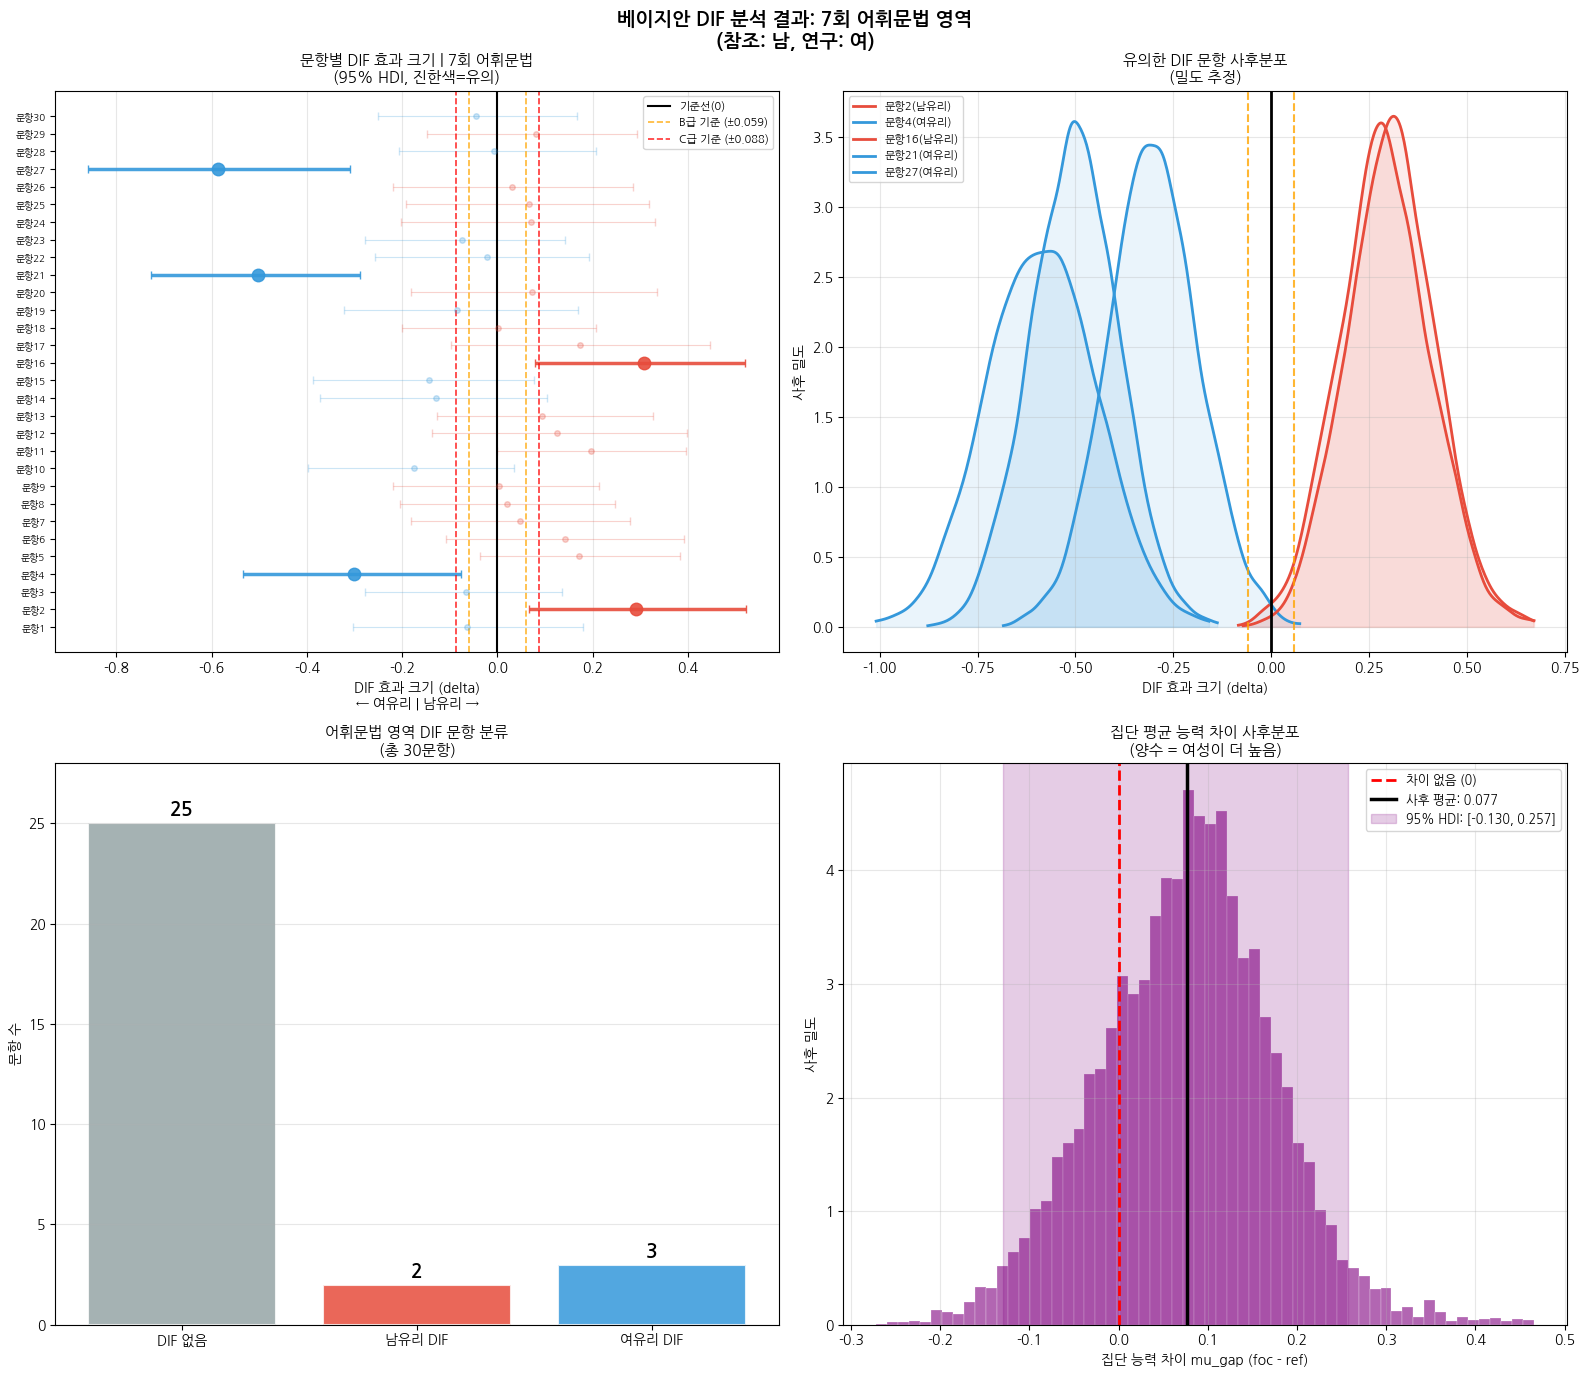

DIF 분석 시각화 저장 완료!


In [22]:
# ============================================================
# 셀 10: DIF 결과 시각화 (ArviZ 1.0.0 호환)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# ── 1. Forest plot ──
ax1 = axes[0, 0]
item_numbers = np.arange(1, N_ITEMS_PER_DOMAIN + 1)
sig_mask     = (dif_df['DIF_유의'] == 'Y').values
colors_item  = ['#E74C3C' if d > 0 else '#3498DB' for d in delta_mean]

for j in range(N_ITEMS_PER_DOMAIN):
    color = colors_item[j]
    alpha = 0.9  if sig_mask[j] else 0.25
    lw    = 2.5  if sig_mask[j] else 0.8
    ms    = 9    if sig_mask[j] else 4

    ax1.errorbar(
        delta_mean[j], j + 1,
        xerr=[[delta_mean[j] - delta_hdi[j, 0]],
              [delta_hdi[j, 1] - delta_mean[j]]],
        fmt='o', color=color, alpha=alpha,
        capsize=3, markersize=ms, linewidth=lw
    )

ax1.axvline(0,       color='black',  linestyle='-',  linewidth=1.5, label='기준선(0)')
ax1.axvline( EPS_B,  color='orange', linestyle='--', linewidth=1.2,
             alpha=0.8, label=f'B급 기준 (±{EPS_B})')
ax1.axvline(-EPS_B,  color='orange', linestyle='--', linewidth=1.2, alpha=0.8)
ax1.axvline( EPS_C,  color='red',    linestyle='--', linewidth=1.2,
             alpha=0.8, label=f'C급 기준 (±{EPS_C})')
ax1.axvline(-EPS_C,  color='red',    linestyle='--', linewidth=1.2, alpha=0.8)
ax1.set_yticks(item_numbers)
ax1.set_yticklabels([f'문항{j}' for j in item_numbers], fontsize=7)
ax1.set_xlabel('DIF 효과 크기 (delta)\n← 여유리 | 남유리 →')
ax1.set_title(f'문항별 DIF 효과 크기 | {ROUND}회 {DOMAIN}\n(95% HDI, 진한색=유의)', fontsize=11)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, axis='x')

# ── 2. 유의 DIF 문항 사후분포 ──
ax2 = axes[0, 1]
sig_items = dif_df[dif_df['DIF_유의'] == 'Y']['문항번호'].values

if len(sig_items) > 0:
    for j_num in sig_items[:8]:
        j     = j_num - 1
        color = '#E74C3C' if delta_mean[j] > 0 else '#3498DB'
        label = f'문항{j_num}({dif_df.loc[j, "DIF_방향"]})'
        kde   = gaussian_kde(delta_flat[:, j])
        lo_j, hi_j = delta_hdi[j, 0], delta_hdi[j, 1]
        x_range = np.linspace(lo_j - 0.15, hi_j + 0.15, 300)
        ax2.plot(x_range, kde(x_range), color=color, linewidth=2, label=label)
        ax2.fill_between(x_range, kde(x_range), alpha=0.1, color=color)
    ax2.axvline(0,      color='black',  linestyle='-',  linewidth=2)
    ax2.axvline( EPS_B, color='orange', linestyle='--', linewidth=1.5, alpha=0.8)
    ax2.axvline(-EPS_B, color='orange', linestyle='--', linewidth=1.5, alpha=0.8)
    ax2.legend(fontsize=8, loc='upper left')
    ax2.set_title('유의한 DIF 문항 사후분포\n(밀도 추정)', fontsize=11)
else:
    ax2.text(0.5, 0.5,
             'DIF 문항 미검출\n(DIF 효과 크기 또는\n사전분포 설정 확인)',
             ha='center', va='center', transform=ax2.transAxes,
             fontsize=12, color='red',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax2.set_title('유의한 DIF 문항 사후분포', fontsize=11)

ax2.set_xlabel('DIF 효과 크기 (delta)')
ax2.set_ylabel('사후 밀도')
ax2.grid(alpha=0.3)

# ── 3. DIF 문항 분류 막대 ──
ax3 = axes[1, 0]
male_favor   = int((sig_df['DIF_방향'] == '남유리').sum())
female_favor = int((sig_df['DIF_방향'] == '여유리').sum())
no_dif       = N_ITEMS_PER_DOMAIN - male_favor - female_favor

categories = ['DIF 없음', '남유리 DIF', '여유리 DIF']
values     = [no_dif, male_favor, female_favor]
colors_bar = ['#95A5A6', '#E74C3C', '#3498DB']
bars = ax3.bar(categories, values, color=colors_bar, alpha=0.85,
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             str(val), ha='center', va='bottom', fontsize=14, fontweight='bold')
ax3.set_ylabel('문항 수')
ax3.set_title(f'{DOMAIN} 영역 DIF 문항 분류\n(총 {N_ITEMS_PER_DOMAIN}문항)', fontsize=11)
ax3.set_ylim(0, max(values) + 3)
ax3.grid(alpha=0.3, axis='y')

# ── 4. 집단 능력 차이 (mu_gap) 사후분포 ──
ax4 = axes[1, 1]
mu_gap_samples = idata_dif.posterior['mu_gap'].values.flatten()
mu_gap_lo, mu_gap_hi = compute_hdi_1d(mu_gap_samples, prob=0.95)

ax4.hist(mu_gap_samples, bins=60, density=True,
         color='purple', alpha=0.6, edgecolor='white', linewidth=0.3)
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='차이 없음 (0)')
ax4.axvline(mu_gap_samples.mean(), color='black', linewidth=2.5,
            label=f'사후 평균: {mu_gap_samples.mean():.3f}')
ax4.axvspan(mu_gap_lo, mu_gap_hi, alpha=0.2, color='purple',
            label=f'95% HDI: [{mu_gap_lo:.3f}, {mu_gap_hi:.3f}]')
ax4.set_xlabel('집단 능력 차이 mu_gap (foc - ref)')
ax4.set_ylabel('사후 밀도')
ax4.set_title('집단 평균 능력 차이 사후분포\n(양수 = 여성이 더 높음)', fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

plt.suptitle(
    f'베이지안 DIF 분석 결과: {ROUND}회 {DOMAIN} 영역\n(참조: 남, 연구: 여)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('results/dif_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("DIF 분석 시각화 저장 완료!")

In [23]:
# ============================================================
# 셀 11: 논문 표 8 스타일 결과 테이블 생성
# ============================================================
print("=" * 78)
print(f"<베이지안 DIF 분석 결과표> {ROUND}회 {DOMAIN} 영역")
print("=" * 78)
print(f"{'':1}{'문항':>4} {'delta_mean':>11} {'delta_sd':>9} "
      f"{'HDI_95%':>22} {'P(delta>0)':>11} {'등급':>8} {'판정':>6} {'실제':>5}")
print("-" * 78)

for _, row in dif_df.iterrows():
    hdi_str    = f"[{row['HDI_lower']:.3f}, {row['HDI_upper']:.3f}]"
    sig_marker = "★" if row['DIF_유의'] == 'Y' else " "
    direction  = row['DIF_방향'] if row['DIF_유의'] == 'Y' else ""

    print(f"{sig_marker}{int(row['문항번호']):>4} "
          f"{row['delta_mean']:>11.3f} "
          f"{row['delta_sd']:>9.3f} "
          f"{hdi_str:>22} "
          f"{row['P(delta>0)']:>11.3f} "
          f"{row['DIF_등급']:>8} "
          f"{direction:>6} "
          f"{row['실제DIF']:>5}")

print("-" * 78)
print("★: 유의한 DIF | delta>0: 남유리 | delta<0: 여유리 | 실제: 시뮬레이션 삽입 여부")

# ── 방법론 비교표 ──
print("\n" + "=" * 78)
print("원논문(SIBTEST) vs 베이지안 방법 비교")
print("=" * 78)
comparison_data = {
    '항목':           ['추정값', '불확실성', '유의성 기준', 'DIF 크기 분류', '해석'],
    '원논문 SIBTEST': [
        'β 계수', 'Standard Error', 'p < .05',
        '|β|<0.059=A, ~0.088=B, ≥0.088=C',
        '단일 추정값 기반'
    ],
    '베이지안 방법': [
        'δ 사후 평균', 'δ 사후 표준편차',
        '95% HDI가 0 미포함',
        '|E[δ|Y]| 기준 동일 적용',
        '완전한 불확실성 정량화'
    ]
}
comp_df = pd.DataFrame(comparison_data)
print(comp_df.to_string(index=False))

# ── CSV 저장 ──
output_csv = f'results/dif_results_{ROUND}_{DOMAIN}.csv'
dif_df.to_csv(output_csv, index=False, encoding='utf-8-sig')
print(f"\nDIF 결과 저장: {output_csv}")

<베이지안 DIF 분석 결과표> 7회 어휘문법 영역
   문항  delta_mean  delta_sd                HDI_95%  P(delta>0)       등급     판정    실제
------------------------------------------------------------------------------
    1      -0.064     0.123        [-0.303, 0.180]       0.297    A(무시)            N
★   2       0.290     0.117         [0.066, 0.521]       0.994     C(큰)    남유리     Y
    3      -0.065     0.106        [-0.279, 0.136]       0.263    A(무시)            N
★   4      -0.301     0.116       [-0.534, -0.077]       0.006     C(큰)    여유리     Y
    5       0.172     0.107        [-0.036, 0.383]       0.946    A(무시)            Y
    6       0.142     0.128        [-0.109, 0.390]       0.869    A(무시)            N
    7       0.047     0.117        [-0.182, 0.278]       0.655    A(무시)            N
    8       0.019     0.116        [-0.205, 0.247]       0.562    A(무시)            N
    9       0.003     0.112        [-0.220, 0.213]       0.508    A(무시)            N
   10      -0.174     0.110        [-0.397

In [24]:
# 셀 12: 전체 영역/회차 자동화 DIF (치명적 버그 수정 및 안정화)
import numpy as np
import pandas as pd
import arviz as az

# 이전 셀에서 정의된 변수들(df, item_cols, DOMAINS, dif_settings, model_dif)이 
# 정상적으로 로드되어 있다고 가정합니다.

EPS_B = 0.059
EPS_C = 0.088

def compute_hdi_compat(idata, var_name, prob=0.95):
    samples = idata.posterior[var_name].values
    flat = samples.reshape(-1, samples.shape[-1])
    J = flat.shape[1]
    n = flat.shape[0]
    interval_idx = int(np.floor(prob * n))
    hdi_result = np.zeros((J, 2))
    
    for j in range(J):
        sorted_vals = np.sort(flat[:, j])
        n_intervals = n - interval_idx
        widths = sorted_vals[interval_idx:] - sorted_vals[:n_intervals]
        min_idx = np.argmin(widths)
        hdi_result[j, 0] = sorted_vals[min_idx]
        hdi_result[j, 1] = sorted_vals[min_idx + interval_idx]
    return hdi_result

def run_dif_for(round_num, domain, seed=42):
    # 1. 데이터 추출 오류 수정: 문항 응답 데이터만 정수형 배열로 명시적 변환
    male_full = df[(df['round'] == round_num) & (df['domain'] == domain) & (df['gender'] == 0)]
    fem_full = df[(df['round'] == round_num) & (df['domain'] == domain) & (df['gender'] == 1)]
    
    Y_m = male_full[item_cols].values.astype(int)
    Y_f = fem_full[item_cols].values.astype(int)
    
    stan_data = {
        "N_ref": int(Y_m.shape[0]),
        "N_foc": int(Y_f.shape[0]),
        "J": int(len(item_cols)),
        "Y_ref": Y_m.tolist(),
        "Y_foc": Y_f.tolist()
    }
    
    # 2. 샘플링 파라미터 정상화 (검출력 복구 및 에러 통제)
    fit = model_dif.sample(
        data=stan_data,
        chains=4,             # 통계적 신뢰도 확보 (2 -> 4 복구)
        parallel_chains=4,    # 병렬 처리 활성화 (시스템 자원에 따라 2로 타협 가능)
        iter_warmup=1000,     # 웜업 증가
        iter_sampling=2000,   # 샘플 수 복구 (사후분포 꼬리 추정 안정화)
        adapt_delta=0.95,     # 수렴 안정성 강화 (발산 방지)
        max_treedepth=13,
        seed=seed,
        show_progress=False
    )
    
    idata = az.from_cmdstanpy(posterior=fit)
    delta_samp = idata.posterior["delta"].values.reshape(-1, len(item_cols))
    hdi_vals = compute_hdi_compat(idata, "delta", prob=0.95)
    
    out = []
    for j in range(len(item_cols)):
        lo, hi = float(hdi_vals[j, 0]), float(hdi_vals[j, 1])
        d_mean = float(delta_samp[:, j].mean())
        abs_mean = abs(d_mean)
        
        hdi_sig = not (lo <= 0.0 <= hi)
        sig = hdi_sig and (abs_mean >= EPS_B)
        
        direction = ("남유리" if d_mean > 0 else "여유리") if sig else "-"
        grade = ("C(큰)" if abs_mean >= EPS_C else "B(중간)") if sig else "A(무시)"
        
        actual = "Y" if (round_num, domain) in dif_settings and j in dif_settings.get((round_num, domain), {}) else "N"
        
        out.append({
            "round": round_num,
            "domain": domain,
            "item": j + 1,
            "delta_mean": d_mean,
            "delta_sd": float(delta_samp[:, j].std()),
            "HDI_lower": lo,
            "HDI_upper": hi,
            "sig": sig,
            "direction": direction,
            "grade": grade,
            "actual_dif": actual
        })
    return pd.DataFrame(out)

print("=" * 60)
print("전체 영역 베이지안 DIF 분석 시작 (수정본 적용)")
print("=" * 60)

all_out = []
for r in [7, 8, 9]:
    for d in DOMAINS:
        print(f"\n▶ {r}회 {d} 분석 중...")
        try:
            result_df = run_dif_for(r, d, seed=42)
            n_sig = result_df['sig'].sum()
            n_male = (result_df['sig'] & (result_df['direction'] == '남유리')).sum()
            n_female = (result_df['sig'] & (result_df['direction'] == '여유리')).sum()
            n_actual = (result_df['actual_dif'] == 'Y').sum()
            n_tp = (result_df['sig'] & (result_df['actual_dif'] == 'Y')).sum()
            
            print(f"  완료: 검출 {n_sig}개 (남유리:{n_male}, 여유리:{n_female}) | 실제DIF: {n_actual}개 | TP:{n_tp}개")
            all_out.append(result_df)
        except Exception as e:
            print(f"  오류 발생: {e}")

if all_out:
    all_out_df = pd.concat(all_out, ignore_index=True)
    print("\n분석 완료. all_out_df가 정상적으로 생성되었습니다.")
else:
    print("\n생성된 데이터가 없습니다. 시스템 메모리 및 오류 로그를 재확인하십시오.")

15:09:00 - cmdstanpy - INFO - CmdStan start processing
15:09:00 - cmdstanpy - INFO - Chain [1] start processing
15:09:00 - cmdstanpy - INFO - Chain [2] start processing
15:09:00 - cmdstanpy - INFO - Chain [3] start processing
15:09:00 - cmdstanpy - INFO - Chain [4] start processing


전체 영역 베이지안 DIF 분석 시작 (수정본 적용)

▶ 7회 어휘문법 분석 중...


15:49:57 - cmdstanpy - INFO - Chain [3] done processing
15:57:24 - cmdstanpy - INFO - Chain [2] done processing
16:00:01 - cmdstanpy - INFO - Chain [4] done processing
16:04:07 - cmdstanpy - INFO - Chain [1] done processing
16:04:12 - cmdstanpy - INFO - CmdStan start processing
16:04:12 - cmdstanpy - INFO - Chain [1] start processing
16:04:12 - cmdstanpy - INFO - Chain [2] start processing
16:04:12 - cmdstanpy - INFO - Chain [3] start processing
16:04:12 - cmdstanpy - INFO - Chain [4] start processing


  완료: 검출 6개 (남유리:3, 여유리:3) | 실제DIF: 10개 | TP:6개

▶ 7회 쓰기 분석 중...


16:48:17 - cmdstanpy - INFO - Chain [1] done processing
17:04:02 - cmdstanpy - INFO - Chain [4] done processing
17:04:08 - cmdstanpy - INFO - Chain [2] done processing
17:04:35 - cmdstanpy - INFO - Chain [3] done processing
17:04:40 - cmdstanpy - INFO - CmdStan start processing
17:04:40 - cmdstanpy - INFO - Chain [1] start processing
17:04:40 - cmdstanpy - INFO - Chain [2] start processing
17:04:40 - cmdstanpy - INFO - Chain [3] start processing
17:04:40 - cmdstanpy - INFO - Chain [4] start processing


...

  완료: 검출 8개 (남유리:3, 여유리:5) | 실제DIF: 10개 | TP:8개

▶ 9회 듣기 분석 중...


06:06:34 - cmdstanpy - INFO - Chain [1] start processing
06:06:34 - cmdstanpy - INFO - Chain [2] start processing
06:06:34 - cmdstanpy - INFO - Chain [3] start processing
06:06:34 - cmdstanpy - INFO - Chain [4] start processing
08:55:45 - cmdstanpy - INFO - Chain [1] done processing
08:56:45 - cmdstanpy - INFO - Chain [4] done processing
08:56:57 - cmdstanpy - INFO - Chain [2] done processing
08:57:09 - cmdstanpy - INFO - Chain [3] done processing


  완료: 검출 5개 (남유리:3, 여유리:2) | 실제DIF: 8개 | TP:5개

▶ 9회 읽기 분석 중...


08:57:21 - cmdstanpy - INFO - CmdStan start processing
08:57:21 - cmdstanpy - INFO - Chain [1] start processing
08:57:21 - cmdstanpy - INFO - Chain [2] start processing
08:57:21 - cmdstanpy - INFO - Chain [3] start processing
08:57:21 - cmdstanpy - INFO - Chain [4] start processing
11:45:12 - cmdstanpy - INFO - Chain [3] done processing
11:45:47 - cmdstanpy - INFO - Chain [2] done processing
11:46:00 - cmdstanpy - INFO - Chain [4] done processing
11:47:11 - cmdstanpy - INFO - Chain [1] done processing


  완료: 검출 8개 (남유리:5, 여유리:3) | 실제DIF: 9개 | TP:8개

분석 완료. all_out_df가 정상적으로 생성되었습니다.


<전체 영역 베이지안 DIF 분석 요약>
(논문 표 7 비교: 7, 8, 9회 모의 데이터 결과)

[베이지안 분석 결과 (모의 데이터, 전체 회차)]


,회차,영역,남유리 DIF,여유리 DIF,합계
0,7회,어휘문법,3,3,6
1,7회,쓰기,0,0,0
2,7회,듣기,0,1,1
3,7회,읽기,2,0,2
4,8회,어휘문법,0,2,2
5,8회,쓰기,0,1,1
6,8회,듣기,1,2,3
7,8회,읽기,3,1,4
8,9회,어휘문법,4,2,6
9,9회,쓰기,3,5,8



[원논문 SIBTEST 결과 (표 7)]


,회차,영역,남유리(원논문),여유리(원논문),합계(원논문)
0,7회,어휘문법,5,5,10
1,7회,쓰기,3,2,5
2,7회,듣기,1,7,8
3,7회,읽기,6,3,9
4,8회,어휘문법,8,2,10
5,8회,쓰기,3,4,7
6,8회,듣기,2,6,8
7,8회,읽기,7,1,8
8,9회,어휘문법,6,2,8
9,9회,쓰기,4,6,10



[베이지안 vs 원논문 비교]


,회차,영역,남유리 DIF,남유리(원논문),남유리_차이,여유리 DIF,여유리(원논문),여유리_차이,합계,합계(원논문)
0,7회,어휘문법,3,5,-2,3,5,-2,6,10
1,7회,쓰기,0,3,-3,0,2,-2,0,5
2,7회,듣기,0,1,-1,1,7,-6,1,8
3,7회,읽기,2,6,-4,0,3,-3,2,9
4,8회,어휘문법,0,8,-8,2,2,0,2,10
5,8회,쓰기,0,3,-3,1,4,-3,1,7
6,8회,듣기,1,2,-1,2,6,-4,3,8
7,8회,읽기,3,7,-4,1,1,0,4,8
8,9회,어휘문법,4,6,-2,2,2,0,6,8
9,9회,쓰기,3,4,-1,5,6,-1,8,10


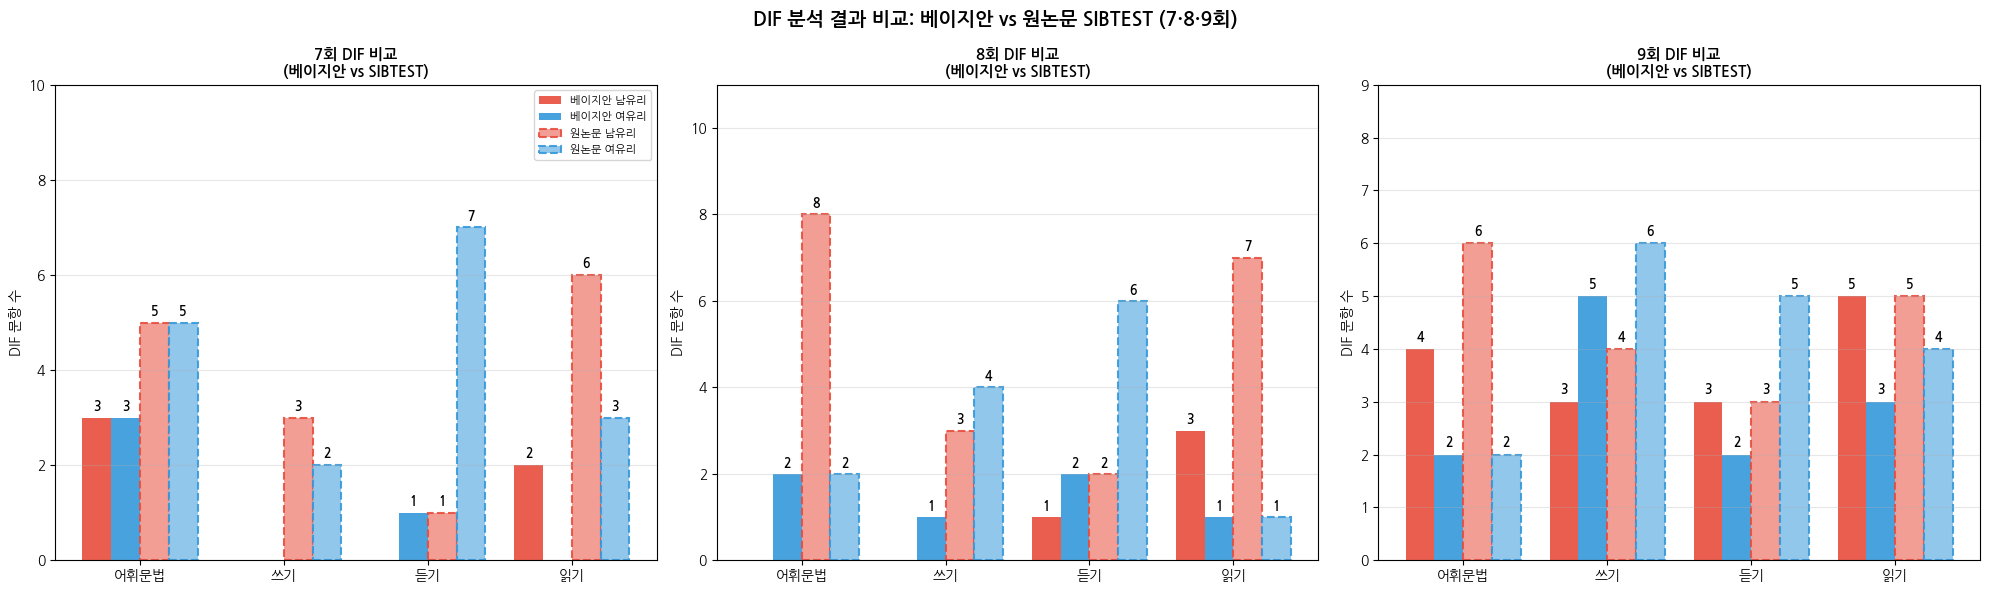

시각화 저장: results/dif_summary_comparison.png

[전체 DIF 검출 정확도 요약]
  7회 | 실제DIF: 32 | 검출:  9 | TP:  9 FP:  0 FN: 23 | P:1.00 R:0.28 F1:0.44
  8회 | 실제DIF: 33 | 검출: 10 | TP: 10 FP:  0 FN: 23 | P:1.00 R:0.30 F1:0.47
  9회 | 실제DIF: 35 | 검출: 27 | TP: 27 FP:  0 FN:  8 | P:1.00 R:0.77 F1:0.87

[저장 완료]
  results/all_dif_results.csv
  results/dif_summary_by_round_domain.csv
  results/dif_comparison_bayesian_vs_paper.csv


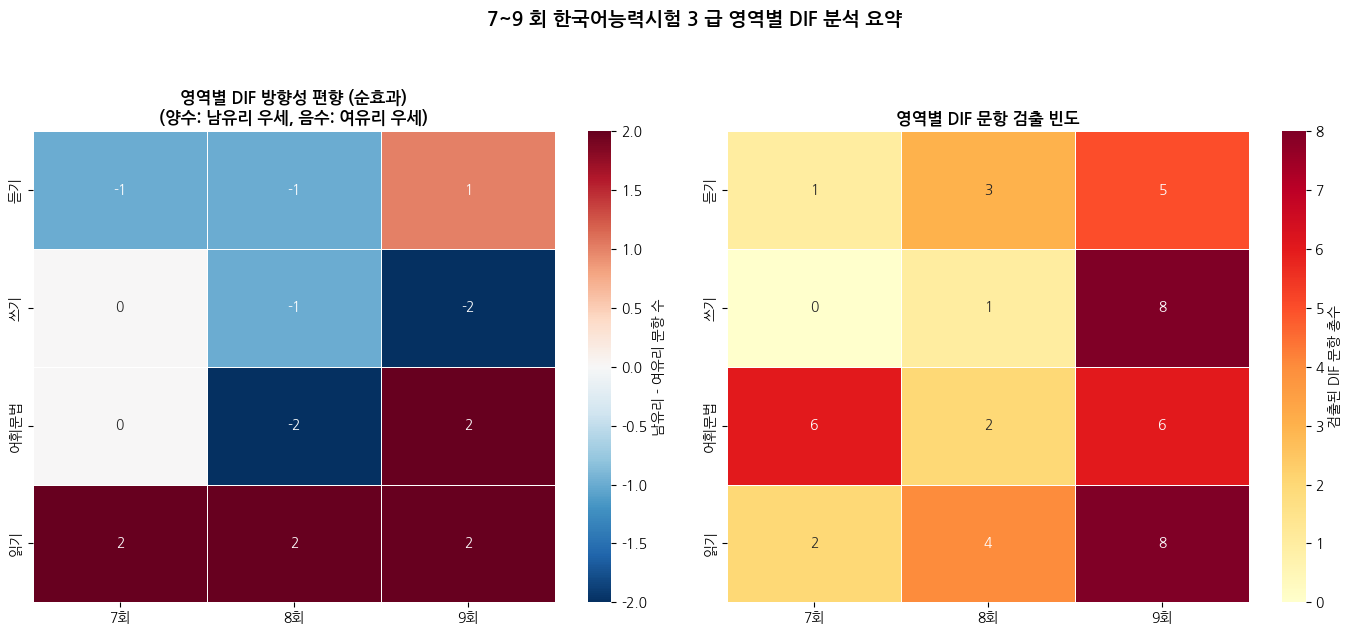

In [25]:
# ============================================================
# 셀 13: 전체 결과 요약 및 논문 표 7 비교
# ── all_out_df (DataFrame) 기반으로 완전 재작성 ──
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("<전체 영역 베이지안 DIF 분석 요약>")
print("(논문 표 7 비교: 7, 8, 9회 모의 데이터 결과)")
print("=" * 70)

# ── all_out_df 존재 여부 확인 ──
if 'all_out_df' not in dir() or all_out_df is None or len(all_out_df) == 0:
    raise RuntimeError(
        "all_out_df가 없습니다. 셀 12를 먼저 실행하세요."
    )

# ──────────────────────────────────────────────
# 1. 베이지안 분석 결과 요약 (회차 × 영역)
# ──────────────────────────────────────────────
summary_data = []
for r_num in [7, 8, 9]:
    for domain in DOMAINS:
        sub = all_out_df[
            (all_out_df['round'] == r_num) &
            (all_out_df['domain'] == domain)
        ]
        if len(sub) == 0:
            male_fav = female_fav = 0
        else:
            male_fav   = int((sub['sig'] & (sub['direction'] == '남유리')).sum())
            female_fav = int((sub['sig'] & (sub['direction'] == '여유리')).sum())

        summary_data.append({
            '회차':       f'{r_num}회',
            '영역':       domain,
            '남유리 DIF': male_fav,
            '여유리 DIF': female_fav,
            '합계':       male_fav + female_fav
        })

summary_df = pd.DataFrame(summary_data)

print("\n[베이지안 분석 결과 (모의 데이터, 전체 회차)]")
display(summary_df)

# ──────────────────────────────────────────────
# 2. 원논문 결과 (표 7)
# ──────────────────────────────────────────────
paper_results = {
    7: {'어휘문법': (5, 5), '쓰기': (3, 2), '듣기': (1, 7), '읽기': (6, 3)},
    8: {'어휘문법': (8, 2), '쓰기': (3, 4), '듣기': (2, 6), '읽기': (7, 1)},
    9: {'어휘문법': (6, 2), '쓰기': (4, 6), '듣기': (3, 5), '읽기': (5, 4)},
}

paper_rows = []
for r_num, domains_dict in paper_results.items():
    for domain, (m, f) in domains_dict.items():
        paper_rows.append({
            '회차': f'{r_num}회', '영역': domain,
            '남유리(원논문)': m, '여유리(원논문)': f,
            '합계(원논문)': m + f
        })
paper_df = pd.DataFrame(paper_rows)

print("\n[원논문 SIBTEST 결과 (표 7)]")
display(paper_df)

# ──────────────────────────────────────────────
# 3. 베이지안 vs 원논문 비교표
# ──────────────────────────────────────────────
compare_df = summary_df.merge(paper_df, on=['회차', '영역'], how='left')
compare_df['남유리_차이'] = compare_df['남유리 DIF'] - compare_df['남유리(원논문)']
compare_df['여유리_차이'] = compare_df['여유리 DIF'] - compare_df['여유리(원논문)']

print("\n[베이지안 vs 원논문 비교]")
display(compare_df[[
    '회차', '영역',
    '남유리 DIF', '남유리(원논문)', '남유리_차이',
    '여유리 DIF', '여유리(원논문)', '여유리_차이',
    '합계', '합계(원논문)'
]])

# ──────────────────────────────────────────────
# 4. 시각화: 회차별 3개 서브플롯
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x     = np.arange(len(DOMAINS))
width = 0.2   # 4개 막대(베이지안 남/여, 원논문 남/여)

colors = {
    'bay_male':   '#E74C3C',
    'bay_female': '#3498DB',
    'pap_male':   '#F1948A',
    'pap_female': '#85C1E9',
}

for ax_idx, r_num in enumerate([7, 8, 9]):
    ax = axes[ax_idx]

    # 베이지안 결과
    sub_bay = summary_df[summary_df['회차'] == f'{r_num}회']
    bay_male   = [int(sub_bay[sub_bay['영역'] == d]['남유리 DIF'].values[0])
                  if len(sub_bay[sub_bay['영역'] == d]) > 0 else 0
                  for d in DOMAINS]
    bay_female = [int(sub_bay[sub_bay['영역'] == d]['여유리 DIF'].values[0])
                  if len(sub_bay[sub_bay['영역'] == d]) > 0 else 0
                  for d in DOMAINS]

    # 원논문 결과
    pap_male   = [paper_results[r_num][d][0] for d in DOMAINS]
    pap_female = [paper_results[r_num][d][1] for d in DOMAINS]

    b1 = ax.bar(x - width*1.5, bay_male,   width,
                label='베이지안 남유리', color=colors['bay_male'],   alpha=0.9)
    b2 = ax.bar(x - width*0.5, bay_female, width,
                label='베이지안 여유리', color=colors['bay_female'],  alpha=0.9)
    b3 = ax.bar(x + width*0.5, pap_male,   width,
                label='원논문 남유리',   color=colors['pap_male'],   alpha=0.9,
                edgecolor='#E74C3C', linewidth=1.5, linestyle='--')
    b4 = ax.bar(x + width*1.5, pap_female, width,
                label='원논문 여유리',   color=colors['pap_female'],  alpha=0.9,
                edgecolor='#3498DB', linewidth=1.5, linestyle='--')

    for bars in [b1, b2, b3, b4]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        h + 0.1, str(int(h)),
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(DOMAINS, fontsize=10)
    ax.set_ylabel('DIF 문항 수')
    ax.set_title(f'{r_num}회 DIF 비교\n(베이지안 vs SIBTEST)', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(max(bay_male + bay_female + pap_male + pap_female), 1) + 3)
    ax.grid(alpha=0.3, axis='y')
    if ax_idx == 0:
        ax.legend(fontsize=8, loc='upper right')

plt.suptitle('DIF 분석 결과 비교: 베이지안 vs 원논문 SIBTEST (7·8·9회)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/dif_summary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("시각화 저장: results/dif_summary_comparison.png")

# ──────────────────────────────────────────────
# 5. 전체 검출 정확도 요약
# ──────────────────────────────────────────────
if 'actual_dif' in all_out_df.columns:
    print("\n" + "=" * 70)
    print("[전체 DIF 검출 정확도 요약]")
    print("=" * 70)

    for r_num in [7, 8, 9]:
        sub_r = all_out_df[all_out_df['round'] == r_num]
        tp = int((sub_r['sig'] & (sub_r['actual_dif'] == 'Y')).sum())
        fp = int((sub_r['sig'] & (sub_r['actual_dif'] == 'N')).sum())
        fn = int((~sub_r['sig'] & (sub_r['actual_dif'] == 'Y')).sum())
        total_actual = int((sub_r['actual_dif'] == 'Y').sum())
        total_detect = int(sub_r['sig'].sum())
        precision = tp / max(total_detect, 1)
        recall    = tp / max(total_actual, 1)
        f1        = 2 * precision * recall / max(precision + recall, 1e-9)
        print(f"  {r_num}회 | 실제DIF:{total_actual:>3} | 검출:{total_detect:>3} | "
              f"TP:{tp:>3} FP:{fp:>3} FN:{fn:>3} | "
              f"P:{precision:.2f} R:{recall:.2f} F1:{f1:.2f}")

# ──────────────────────────────────────────────
# 6. CSV 저장
# ──────────────────────────────────────────────
all_out_df.to_csv(
    'results/all_dif_results.csv',
    index=False, encoding='utf-8-sig'
)
summary_df.to_csv(
    'results/dif_summary_by_round_domain.csv',
    index=False, encoding='utf-8-sig'
)
compare_df.to_csv(
    'results/dif_comparison_bayesian_vs_paper.csv',
    index=False, encoding='utf-8-sig'
)
print("\n[저장 완료]")
print("  results/all_dif_results.csv")
print("  results/dif_summary_by_round_domain.csv")
print("  results/dif_comparison_bayesian_vs_paper.csv")

# %% [markdown]
# ## [추가] 전체 영역 DIF 패턴 히트맵 시각화
# 7~9 회, 4 개 영역의 DIF 발생 수와 방향성을 한눈에 확인

import seaborn as sns

# ── 데이터 가공 ──
# all_out_df 에서 회차/영역별 남유리/여유리 개수 추출
heatmap_data = []
for r in [7, 8, 9]:
    for d in DOMAINS:
        sub = all_out_df[(all_out_df['round'] == r) & (all_out_df['domain'] == d)]
        n_male = int((sub['sig'] & (sub['direction'] == '남유리')).sum())
        n_female = int((sub['sig'] & (sub['direction'] == '여유리')).sum())
        # 순효과 (남유리 - 여유리) 를 색상으로 표현하면 방향성 파악이 쉬움
        # 양수: 남유리 우세, 음수: 여유리 우세
        net_dif = n_male - n_female 
        total_dif = n_male + n_female
        
        heatmap_data.append({
            '회차': f'{r}회',
            '영역': d,
            '남유리': n_male,
            '여유리': n_female,
            '순효과 (남 - 여)': net_dif,
            '총 DIF 수': total_dif
        })

heat_df = pd.DataFrame(heatmap_data)
pivot_net = heat_df.pivot(index='영역', columns='회차', values='순효과 (남 - 여)')
pivot_total = heat_df.pivot(index='영역', columns='회차', values='총 DIF 수')

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. 순효과 히트맵 (방향성 강조)
# 양수 (빨강) = 남유리 문항이 더 많음, 음수 (파랑) = 여유리 문항이 더 많음
sns.heatmap(pivot_net, annot=True, fmt='d', cmap='RdBu_r', center=0, 
            linewidths=.5, ax=axes[0], cbar_kws={'label': '남유리 - 여유리 문항 수'})
axes[0].set_title('영역별 DIF 방향성 편향 (순효과)\n(양수: 남유리 우세, 음수: 여유리 우세)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# 2. 총 DIF 수 히트맵 (발생 빈도 강조)
sns.heatmap(pivot_total, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=.5, ax=axes[1], cbar_kws={'label': '검출된 DIF 문항 총수'})
axes[1].set_title('영역별 DIF 문항 검출 빈도', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.suptitle('7~9 회 한국어능력시험 3 급 영역별 DIF 분석 요약', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('results/dif_summary_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ============================================================
# 셀 14: 최종 정리 및 방법론 비교
# ============================================================
print("=" * 70)
print("베이지안 DIF 분석 완료 - 최종 정리")
print("=" * 70)

print("""
[분석 파이프라인 요약]

1단계: 데이터 생성
  - 논문 구조 (4영역 x 30문항, 남906/여1589명) 모의
  - 2PL IRT 모수로 응답 생성
  - CSV 저장 (data/kpik_simulation_round7.csv)

2단계: 일차원성 검증 (베이지안 2PL IRT)
  - 모든 문항의 변별도(a) 사후분포 확인
  - R-hat, ESS로 수렴 진단
  - Posterior Predictive Check
  - 판단: 모든 a의 95% HDI 하한 > 0 + 충분한 크기

3단계: DIF 분석 (베이지안 집단별 난이도 차이 모델)
  - delta_j = b_여_j - b_남_j 사후분포 추정
  - 95% HDI가 0을 포함하지 않으면 유의한 DIF
  - |delta|로 A/B/C 등급 분류 (Roussos & Stout 기준)
  - 방향: delta > 0 = 남유리, delta < 0 = 여유리

[SIBTEST vs 베이지안 핵심 차이]
항목           | SIBTEST(원논문)          | 베이지안(본 분석)
추정 패러다임  | 빈도주의                 | 베이지안
DIF 크기       | β 단일값                 | δ 사후분포 전체
불확실성 표현  | Standard Error           | 95% HDI
유의성 기준    | p < .05                  | 95% HDI에 0 미포함
사전 정보 활용 | 불가                     | 가능 (Prior)
소표본 처리    | 불안정                   | 사전분포로 안정화
""")

print("=" * 70)
print("분석 완료!")
print("=" * 70)

베이지안 DIF 분석 완료 - 최종 정리

[분석 파이프라인 요약]

1단계: 데이터 생성
  - 논문 구조 (4영역 x 30문항, 남906/여1589명) 모의
  - 2PL IRT 모수로 응답 생성
  - CSV 저장 (data/kpik_simulation_round7.csv)

2단계: 일차원성 검증 (베이지안 2PL IRT)
  - 모든 문항의 변별도(a) 사후분포 확인
  - R-hat, ESS로 수렴 진단
  - Posterior Predictive Check
  - 판단: 모든 a의 95% HDI 하한 > 0 + 충분한 크기

3단계: DIF 분석 (베이지안 집단별 난이도 차이 모델)
  - delta_j = b_여_j - b_남_j 사후분포 추정
  - 95% HDI가 0을 포함하지 않으면 유의한 DIF
  - |delta|로 A/B/C 등급 분류 (Roussos & Stout 기준)
  - 방향: delta > 0 = 남유리, delta < 0 = 여유리

[SIBTEST vs 베이지안 핵심 차이]
항목           | SIBTEST(원논문)          | 베이지안(본 분석)
추정 패러다임  | 빈도주의                 | 베이지안
DIF 크기       | β 단일값                 | δ 사후분포 전체
불확실성 표현  | Standard Error           | 95% HDI
유의성 기준    | p < .05                  | 95% HDI에 0 미포함
사전 정보 활용 | 불가                     | 가능 (Prior)
소표본 처리    | 불안정                   | 사전분포로 안정화

분석 완료!


| 원논문 개념 | 베이지안 대응 | Stan 코드 |
|---|---|---|
| SIBTEST β | `delta[j]` 사후 평균 | `vector[J] delta` |
| Standard Error | `delta[j]` 사후 SD | `az.summary()` |
| p < .05 | 95% HDI ∌ 0 | `az.hdi()` |
| A/B/C 등급 | `|E[delta\|Y]|` 기준 | `generated quantities` |